# Listing Radar

## Introduction

RISEx lists perpetual futures. Listing decisions require systematic candidate discovery before safety assessment. This notebook answers the upstream question: **"Which assets are worth reviewing next?"** - it does not approve listings.

**Workflow position:**

| Step | Notebook | Question |
|---|---|---|
| 1 | This notebook | Worth reviewing? |
| 2 | `02_token_listing_evaluation.ipynb` | Safe to list? At what tier? |

A high radar score means *review soon*, not *list*. The listing framework and OI risk notebook are the final authorities.

**Outputs:**

| Output | Description |
|---|---|
| Ranked candidate table | Top-N unlisted assets by radar score R ∈ [0, 100] |
| Component detail table | Per-candidate sub-scores, raw values, contextual signals |

---
## Methodology

### Scoring formula

Five buckets, empirically calibrated:

$$R = 20 \cdot S_{\text{att}} + 15 \cdot S_{\text{price}} + 25 \cdot S_{\text{vol}} + 25 \cdot S_{\text{OI}} + 15 \cdot S_{\text{lev}}, \qquad R \in [0,\,100]$$

| Bucket | Weight | Sub-components |
|---|---:|---|
| **Market Attention** | 20 | Sentiment (0.60), Technical 1h/1d blend (0.40) |
| **Price Action** | 15 | 1h price move (0.25), 24h price change (0.25), 7d direction consistency (0.25), BTC correlation divergence 30d (0.25) |
| **Volume Acceleration** | 25 | Perp vol accel 7d/24h/spot-spike blend (0.50), P/S ratio level+trend (0.50) |
| **OI Growth** | 25 | OI Spearman trend 7d/30d (0.60), OI/Vol ratio (0.40) |
| **Funding Rate** | 15 | Funding level (0.45), Funding flip 72h decay (0.35), Funding 7d persistence (0.20) |

All sub-scores are normalised to $[0, 1]$. If a sub-component is unavailable (`None`), it is treated as 0 in the weighted sum; its weight is **not** redistributed to other sub-scores. A fully-missing bucket (all sub-scores `None`) contributes 0 to $R$.

Bucket weights set via distribution analysis and forward-return proxy backtest on a 45-token cache. Refine as listing history accumulates.

---

### Normalization methods

| Method | Formula | Applied to |
|---|---|---|
| Clamp (linear) | $\min(1,\; \max(0,\; x/\theta))$ | Price moves, P/S trend, funding level |
| Clamp (log) | $\text{clamp}(\ln(x/x_0)/\ln N,\; 0,\; 1)$ | Volume acceleration (7d: $N=2$, 24h: $N=4$, spot: $N=1.5$) |
| Trapezoid | $0$ outside $[x_0, x_1]$; $1$ in $[x_l, x_r]$; linear ramps | OI/Vol ratio (0 at 0.05 and 3.2; full in [0.2, 0.8]); P/S level (0 at $\le 0.5$ and $\ge 15$; full in $[2.5, 7.5]$) |
| Direct scale | $x / x_{\max}$ | Sentiment (max 10), technical (max 10), direction win rate, funding persistence |
| Decorrelation | $\max(0,\; 1 - \lvert\rho\rvert)$ | BTC 30d return correlation |
| Spearman clamp | $\max(0,\; \rho)$ | OI trend ($\rho \in [-1,1]$; clamp removes declining-OI values) |

Log scaling applies to volume ratios because these span multiple orders of magnitude. A jump from 1x to 2x feels as significant as a jump from 2x to 4x. The denominator $\ln N$ normalises so that ratio $= N$ gives a score of exactly 1.

---

### Metric Details

---

**1h Price Move** ($s_{\text{1h}}$)

- **What:** Maximum positive open-to-close return across the last 12 completed 1h candles (12h lookback window).
- **Rationale:** 1h granularity catches fast breakouts before the 24h ticker reflects them. Taking the max over 12 candles avoids penalising momentum that straddles a candle boundary and provides the same 12h coverage as the prior 4h design. Negative returns score 0.
- **Interpret:** 5% in one 1h candle = full score. Threshold judgment-based; refine as listing history accumulates.

$$s_{\text{1h}} = \text{clamp}\!\left(\frac{\max(r_1,\, \ldots,\, r_{12})}{0.05},\; 0,\; 1\right), \qquad r_i = \frac{\text{close}_i - \text{open}_i}{\text{open}_i} \text{ (positive only)}$$

---

**24h Price Change** ($s_{\text{24h}}$)

- **What:** Rolling 24h price change from the Binance spot ticker, positive only.
- **Rationale:** The universe construction selects tokens with high $\lvert\Delta\text{price}\rvert$, so this sub-score rewards directionality within that pool. Negative dayChange scores 0 (not treated as missing: the data exists, the direction is wrong).
- **Interpret:** 20% in 24h = full score.

$$s_{\text{24h}} = \text{clamp}\!\left(\frac{\text{dayChange}}{0.20},\; 0,\; 1\right)$$

---

**7d Direction Consistency** ($s_{\text{dir}}$)

- **What:** Fraction of the last 7 daily closes that exceeded the prior close (close-to-close, not open-to-close within a candle).
- **Rationale:** A single large candle produces high $s_{\text{24h}}$ but tells nothing about the preceding 6 days. Persistent day-over-day gains suggest a sustained catalyst, not a one-day pump. Close-to-close is used because it captures the realised return for an overnight position (`close > open` within a candle would miss a day that opened higher and closed lower than the prior close).
- **Interpret:** 1.0 = 7 consecutive up-closes. 4/7 = 0.57. All 7 down = 0.

$$s_{\text{dir}} = \frac{1}{7}\sum_{i=1}^{7} \mathbf{1}[\text{close}_i > \text{close}_{i-1}]$$

---

**BTC Correlation Divergence (30d)** ($s_{\text{corr}}$)

- **What:** Decorrelation of the token's daily log-returns from BTC over the past 30 days.
- **Rationale:** A token moving in lockstep with BTC is driven by macro sentiment, not its own catalyst. Decorrelation below $\lvert\rho\rvert < 0.3$ signals an independent driver - a necessary condition for genuine listing demand. BTC klines are fetched once and shared across all candidates.
- **Interpret:** $\rho \approx 0$ = fully independent (score = 1.0). $\lvert\rho\rvert \approx 1$ = BTC proxy (score = 0). Most altcoins sit at $\rho \in [0.5, 0.8]$ in trending markets; decorrelation below 0.3 is meaningful.

The Pearson correlation coefficient:

$$r_{xy} = \frac{\displaystyle\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\displaystyle\sum_{i=1}^{n}(x_i-\bar{x})^2} \cdot \sqrt{\displaystyle\sum_{i=1}^{n}(y_i-\bar{y})^2}}$$

Applied with $x_i = \ln(P_i/P_{i-1})$ and $y_i = \ln(P^{\text{BTC}}_i / P^{\text{BTC}}_{i-1})$ over $n = 30$ daily returns:

$$\rho_{\text{BTC}} = r_{xy}, \qquad s_{\text{corr}} = \max\!\left(0,\; 1 - \lvert\rho_{\text{BTC}}\rvert\right)$$

---

**Perp Volume Acceleration** ($s_{\text{accel}}$)

- **What:** Blend of 7d average perp vol, 24h perp vol, and 24h spot vol — each relative to a rolling baseline, log-scaled.
- **Rationale:** A 7d/30d ratio smooths single-day noise while still capturing sustained breakouts. The 24h component adds recency. Spot spike (spot 24h vs spot 7d avg) detects breakouts on DEX/spot before perp volume follows. Log scaling handles wide volume ratios. The \$10M floor on 24h perp volume removes noise spikes on illiquid assets.
- **Interpret:** 7d ceiling = 2× (full score when 7d avg is 2× the 30d avg). 24h ceiling = 4×. Spot ceiling = 1.5×. Weights: 7d=0.50, 24h=0.30, spot=0.20.

$$s_{\text{accel,7d}} = \text{clamp}\!\left(\frac{\ln(\overline{V}_{7d} / \overline{V}_{30d})}{\ln 2},\; 0,\; 1\right), \qquad s_{\text{accel,24h}} = \text{clamp}\!\left(\frac{\ln(V_{24h} / \overline{V}_{30d})}{\ln 4},\; 0,\; 1\right) \quad \text{if } V_{24h} > \$10\text{M}$$

$$s_{\text{spot}} = \text{clamp}\!\left(\frac{\ln(V_{\text{spot},24h} / \overline{V}_{\text{spot},7d})}{\ln 1.5},\; 0,\; 1\right)$$

$$s_{\text{accel}} = 0.50\, s_{\text{accel,7d}} + 0.30\, s_{\text{accel,24h}} + 0.20\, s_{\text{spot}}$$

---

**Perp/Spot Volume Ratio** ($s_{\text{PS}}$)

- **What:** Ratio of perp to spot volume as a level (current snapshot) and a trend (vs 7-day rolling average).
- **Rationale:** Perp-dominant volume signals that derivatives traders are driving price discovery, a strong fit for a derivatives-first exchange. A rising ratio indicates structural perp demand is building, not just a spot-volume drought.
- **Interpret:** Level > 1 = perp-driven; > 5 = perp-dominant (full score on level). Trend > 30% = structural shift. Threshold raised from 1.5 to 5× to reduce inflation on Alpha tokens where DEX vol is used as the spot proxy.

$$s_{\text{level}} = \text{clamp}\!\left(\frac{\text{ratio}_{\text{now}}}{5.0},\; 0,\; 1\right), \qquad s_{\text{trend}} = \text{clamp}\!\left(\frac{\text{ratio}_{\text{now}} / \overline{\text{ratio}}_{7d} - 1}{0.30},\; 0,\; 1\right)$$

$$s_{\text{PS}} = 0.60\, s_{\text{level}} + 0.40\, s_{\text{trend}}$$

---

**OI Trend (Spearman rank correlation)** ($s_{\text{OI\_trend}}$)

- **What:** Spearman $\rho$ of hourly OI values against time indices $[1, 2, \ldots, n]$. Asks whether OI values tend to rank higher as time progresses.
- **Rationale:** Point-to-point growth misses trajectory. OI flat for 29 days then a +50% spike scores high on growth rate but shows no accumulation trend. Spearman is spike-resistant: a single large OI session moves at most one rank from the tail.
- **Interpret:** $\rho = 1$ = monotonic accumulation. $\rho < 0$ = declining OI (clamped to 0). The 30d window (720 hourly snapshots) is weighted higher than 7d (168 snapshots) because a 24h pump inflates 7d $\rho$ even with no sustained trend.

The Spearman rank correlation:

$$\rho_s = 1 - \frac{6\displaystyle\sum_{i=1}^{n} d_i^2}{n(n^2-1)}, \qquad d_i = \mathrm{rank}(\text{OI}_i) - \mathrm{rank}(i)$$

Applied with $x = [1, 2, \ldots, n]$ (time index) and $y = $ OI values. $\rho_s = 1$ means OI ranks increase monotonically with time.

$$s_{\text{OI},t} = \max(0,\, \rho_s), \qquad s_{\text{OI\_trend}} = 0.40\, s_{\text{OI},7d} + 0.60\, s_{\text{OI},30d}$$

| $\rho$ range | Meaning | $s_{\text{OI}}$ |
|---|---|---|
| 0.80 - 1.00 | Near-monotonic accumulation | 0.80 - 1.00 |
| 0.50 - 0.80 | Clear uptrend with minor reversals | 0.50 - 0.80 |
| 0.20 - 0.50 | Weak or noisy uptrend | 0.20 - 0.50 |
| 0 - 0.20 | Essentially flat | 0 - 0.20 |
| < 0 | Declining OI | 0 (clamped) |

---

**OI / Perp Volume Ratio** ($s_{\text{OI/Vol}}$)

- **What:** Ratio of OI notional (USD) to 24h perp volume (USD). Measures position size relative to daily turnover.
- **Rationale:** Non-monotonic signal — both extremes are bad. Very low OI/Vol (< 0.05) signals churn or wash trading: the market turns over but does not accumulate open interest. Very high OI/Vol (> 3.2) signals leverage stacking relative to thin volume, creating liquidation cascade risk. The sweet spot is moderate position accumulation with healthy trading activity. Calibrated to P25–P75 of the full Binance perp universe (0.234–0.655); healthy band widened to [0.2, 0.8] to accommodate trending mid-caps.
- **Interpret:** Scored via trapezoid: full score in [0.2, 0.8]×; ramps to 0 at 0.05 (churn) and 3.2 (leverage stacking).

**Quadrant intuition:**

| | High OI | Low OI |
|---|---|---|
| **High Vol** | Conviction — active market with genuine position-taking | Churn/wash — volume without commitment |
| **Low Vol** | Leverage stacking — crowded with thin exit | Dead — neither traded nor positioned |

$$s_{\text{OI/Vol}}(x) = \begin{cases} 0 & x \le 0.05 \text{ or } x \ge 3.2 \\ \dfrac{x - 0.05}{0.15} & 0.05 < x < 0.2 \\ 1 & 0.2 \le x \le 0.8 \\ \dfrac{3.2 - x}{2.4} & 0.8 < x < 3.2 \end{cases}, \qquad x = \frac{\text{OI\_notional}}{V_{\text{perp,24h}}}$$

---

**Funding Rate Level** ($s_{\text{fund\_level}}$)

- **What:** Most recent 8h funding rate, positive only.
- **Rationale:** Positive funding means longs pay shorts: the market is net long. Elevated funding (1.5× neutral = 0.015%) is a reliable indicator of speculative long demand. Negative funding (shorts dominant) scores 0.
- **Interpret:** 0.015% per 8h = full score. Typical neutral rate = 0.01%. Threshold calibrated to p80 of observed bull-market distribution.

$$s_{\text{fund\_level}} = \max\!\left(0,\; \text{clamp}\!\left(\frac{f_{\text{last}}}{0.00015},\; 0,\; 1\right)\right)$$

---

**Funding Rate Flip (neg to pos)** ($s_{\text{flip}}$)

- **What:** Recency-weighted signal for a negative-to-positive funding sign change in the past 7 settlements (56h), with linear decay over 72h.
- **Rationale:** A sign reversal means sentiment shifted from net short to net long. Recency matters: a flip 1h ago is a stronger signal than one 70h ago. Tokens with all-positive funding receive a baseline 0.5 (structurally bullish even without a recent flip). Tokens with currently negative funding score 0.
- **Interpret:** Flip 0h ago → 1.0; flip 36h ago → 0.5; flip 72h ago → 0.0; all-positive (no flip) → 0.5; currently negative → 0.

$$s_{\text{flip}} = \begin{cases} \max\!\left(0,\; 1 - \dfrac{t_{\text{since flip}}}{72\text{h}}\right) & \text{neg} \to \text{pos flip found in last 7 settlements} \\ 0.5 & \text{no flip, but last funding rate} > 0 \text{ (all-positive)} \\ 0 & \text{last funding rate} \le 0 \end{cases}$$

---

**Funding 7d Persistence** ($s_{\text{persist}}$)

- **What:** Fraction of the last 21 funding settlements (7 days at 8h intervals) with positive funding.
- **Rationale:** Sustained positive funding over 7 days signals structural long demand, not a single-event squeeze. Distinguishes a token accumulating long interest from one experiencing momentary volatility.
- **Interpret:** 21/21 = 1.0 (all positive). 15/21 = 0.71. 10/21 = 0.48.

$$s_{\text{persist}} = \frac{\text{count}(f_i > 0,\; i \in \text{last 21 settlements})}{21}$$

---

### Hard gates

Both gates must pass. A single failure removes the candidate.

| Gate | Requirement | Source |
|---|---|---|
| **Binance Futures** | Active Binance USD-M Futures market | `fapi/v1/ticker/24hr` |
| **Market cap** | Market cap > $10M | Binance `marketing/symbol/list` `marketCap` |
| **FDV** | FDV >= $50M | Binance spot list / CoinGecko |
| **Perp volume** | Perp 24h vol >= $5M | Binance fapi ticker |
| **Perp DEX listing** | Active perp on Lighter or Hyperliquid | Lighter `orderBookDetails`; Hyperliquid `meta` |

Tokens already listed on RISEx are **not excluded** - they are scored and tagged `already_listed = true` for benchmarking.

---

### Contextual signals (displayed, not scored)

| Signal | Purpose |
|---|---|
| `timing`: PRE / NEW / EST | PRE = no Binance perp yet; first-mover opportunity window |
| `OI notional` | Absolute derivatives market size |
| `OI/Vol ratio` | OI-to-traded-volume; healthy range 0.2–0.8×; extremes signal churn or leverage stacking |
| `P/S ratio` | Current perp dominance level |
| `BTC rho 30d` | Price action independence from macro |
| `Last funding rate` | Current speculative positioning direction |
| `Perp basis` | Current leverage demand premium (display only; not scored) |
| `KOL score` | Influence of top-trader X posts |
| `Social volume` | Absolute 24h social post count |
| `Monitoring` | Token under Binance review (warning: not a hard block) |


---
## Data Sources

All sources are free with no API key required.

| Source | Endpoint | Fields used | Used for |
|---|---|---|---|
| RISEx markets | `api.rise.trade/v1/markets` | `base_asset_symbol` | Already-listed tagging |
| Binance Futures ticker | `fapi/v1/ticker/24hr` | `symbol`, `quoteVolume`, `priceChangePercent` | Universe; perp vol 24h |
| Binance OI history | `futures/data/openInterestHist` (1h, limit=720) | `sumOpenInterest`, `timestamp` | $s_{\text{OI\_trend}}$ (7d + 30d Spearman) |
| Binance klines 1d (futures) | `fapi/v1/klines?interval=1d&limit=35` | quote volume, close prices | $s_{\text{accel}}$ 30d avg; $s_{\text{PS}}$ trend; $s_{\text{dir}}$ close-to-close |
| Binance klines 1h (futures) | `fapi/v1/klines?interval=1h&limit=13` | open, close per candle | $s_{\text{1h}}$ price move (max over last 12 completed candles) |
| Binance klines 1d (spot) | `api.binance.com/api/v3/klines?interval=1d&limit=35` | quote volume per day | $s_{\text{PS}}$ trend; $s_{\text{spot\_spike}}$ 7d avg |
| Binance klines 1d (BTC ref) | `api.binance.com/api/v3/klines?symbol=BTCUSDT&limit=32` | close prices | $s_{\text{corr}}$ BTC 30d correlation -- **one shared fetch** |
| Binance premium index | `fapi/v1/premiumIndex` | `markPrice`, `indexPrice`, `lastFundingRate` | OI notional; $s_{\text{fund\_level}}$; $s_{\text{basis}}$ |
| Binance funding rate history | `fapi/v1/fundingRate?limit=21` | `fundingRate`, `fundingTime` | $s_{\text{flip}}$; $s_{\text{persist}}$ |
| Binance spot list | `bapi/.../marketing/symbol/list` | `baseAsset`, `dayChange`, `volume`, `marketCap`, `tags`, `legalMoney` | Universe; $s_{\text{24h}}$; $s_{\text{OI/MCap}}$; hard gate |
| Binance apex sentiment | `bapi/apex/...?type=sentiment` | `sentiment_score`, `sentiment_score_kol`, `sentiment_24h_social_volume` | $s_{\text{sent}}$; KOL signal; social volume |
| Binance apex technical (1h) | `bapi/apex/...?type=technical&interval=1h` | `technical_score_1h` | $s_{\text{tech}}$ 1h component |
| Binance apex technical (1d) | `bapi/apex/...?type=technical` | `technical_score_1d` | $s_{\text{tech}}$ 1d component |
| CMC unified trending | `data-api/v3/unified-trending/listing` | `tokenSymbol`, `listingRank` | Universe attention filter |
| CoinGecko trending | `api/v3/search/trending` | `item.symbol`, `item.score` | Contextual display only |
| CoinGecko markets | `api/v3/coins/markets` | `symbol`, `market_cap` | MCap fallback for tokens absent from Binance spot |
| DefiLlama protocols | `api.llama.fi/protocols` | `symbol`, `tvl` | Contextual display only |

Cache TTLs: Binance fapi 60 s; funding rate history 5 min; apex sentiment/technical 5 min; spot list 10 min; CMC/CoinGecko 10 min; BTC reference klines 10 min; DefiLlama 30 min. See `script/listing_radar_fetcher.py` for full implementation.

In [1]:
import sys
import time
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import yaml
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent.parent / "script"))
import listing_radar_fetcher as fetcher
from scipy.stats import spearmanr

pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
# ── Configuration ───────────────────────────────────────────────────────────
REFRESH       = True   # True  → bypass all caches and re-fetch from APIs
TOP_N         = 30      # number of candidates in ranked output and YAML export
UNIVERSE_N    = 100     # top-N per Binance spot/futures source (by |dayChange| / quoteVolume)
AUTO_FILL_IDS = True   # True → fetch CoinGecko IDs for YAML export (~4 s × TOP_N)

fetcher.CACHE_DIR = Path("cache/radar")

# ── Universe quality filters ────────────────────────────────────────────────
MIN_FDV_USD      = 50_000_000   # FDV >= $50M
MIN_PERP_VOL_USD =  5_000_000   # perp 24h quote volume >= $5M
MIN_OI_USD       =  1_000_000   # OI notional >= $1M


---
## Step 1 - Data Retrieval

All sources are fetched in parallel. A failure in any single source is isolated - the notebook degrades gracefully and renormalises bucket weights to exclude unavailable sub-components.

In [3]:
raw = fetcher.fetch_all_radar(refresh=REFRESH)

# Source coverage summary
coverage = {k: len(v) for k, v in raw.items()
            if not k.startswith("_") and isinstance(v, (list, dict, set))}
display(pd.DataFrame.from_dict(coverage, orient="index", columns=["records"]).rename_axis("source"))

errors = raw.get("_fetch_errors", {})
if errors:
    warnings.warn(f"Fetch errors: {errors}")
    print("⚠ Degraded sources:", list(errors))
else:
    print("✓ All sources fetched")
print(f"  Binance fapi weight used: {fetcher._weight_monitor.used_weight} / 2400")

,records
source,
binance_spot_list,436
binance_futures_ticker,671
lighter_markets,182
binance_sentiment,383
risex_markets,13
binance_technical,416
binance_technical_1d,416
hyperliquid_markets,230
cg_trending,3


✓ All sources fetched
  Binance fapi weight used: 224 / 2400


---
## Step 2 - Preprocessing

### 2a. Symbol normalisation

Trading pairs (e.g. `SOLUSDT`) are stripped of quote asset suffixes to obtain canonical base symbols (e.g. `SOL`). A manual alias map handles multiplier variants (`1000SHIB` → `SHIB`, etc.).

### 2b. Universe construction

$$\mathcal{U} = \text{CMC\_trending} \cap \left(\text{Binance\_spot\_top}N \cup \text{Binance\_futures\_top}N\right)$$

Intersection filter: token must appear in CMC unified-trending AND at least one of four Binance active sets. Default $N = 100$ per set.

| Binance active set | Sort key | Captures |
|---|---|---|
| Spot top movers | $|\Delta\text{price}_{24h}|$ | Highest absolute price movement |
| Top Gainers | `dayChange` desc (positive only) | Strongest upward momentum |
| Top Volume | 24h spot `volume` desc | Highest liquidity / market interest |
| Futures top | `quoteVolume` desc | Derivatives-driven demand |

### 2c. Hard gates

Both gates must pass. A single failure removes the candidate.

| Gate | Requirement |
|---|---|
| **Binance Futures** | Has an active Binance USD-M Futures market |
| **Market cap** | Market cap > $10M (from Binance spot list) |

Tokens already listed on RISEx are **not excluded**; they are still scored and appear in outputs tagged **Already Listed**, enabling benchmarking against live listings.

The `legalMoney=1` flag (stablecoins and fiat) from the Binance spot list is also excluded. Leveraged/synthetic tokens (`3L`, `BULL`, `BEAR`, etc.) are filtered by pattern.

In [4]:
QUOTE_SUFFIXES = ["USDT", "USDC", "BUSD", "FDUSD", "USDP", "USD"]
ALIAS_MAP = {
    "1000SHIB": "SHIB", "1000BONK": "BONK", "1000PEPE": "PEPE",
    "1000FLOKI": "FLOKI", "1000LUNC": "LUNC", "1000XEC": "XEC",
    "1000SATS": "SATS", "1000BTT": "BTT",
    "1MBABYDOGE": "BABYDOGE", "1000000MOG": "MOG",
    "1000000BABYDOGE": "BABYDOGE",
    "币安人生": "BinanceLife",
}

def normalize_symbol(sym: str) -> str:
    sym = sym.strip().upper()
    for sfx in QUOTE_SUFFIXES:
        if sym.endswith(sfx):
            sym = sym[:-len(sfx)]
            break
    return ALIAS_MAP.get(sym, sym)

STABLECOINS = {
    "USDT","USDC","BUSD","DAI","FDUSD","TUSD","USDD","USDP","GUSD","FRAX",
    "LUSD","SUSD","ALUSD","OUSD","USD1","PYUSD","EURS","EURT","XAUT","PAXG",
    "USDE","SUSDE","RLUSD","USDX","CUSD","EURC",
}
LEVERAGED_PATTERNS = [
    "3L","3S","2L","2S","5L","5S","10L","10S",
    "BULL","BEAR","UP","DOWN","HEDGE","SHORT","LONG",
]

def is_excluded(sym: str) -> bool:
    if sym in STABLECOINS:
        return True
    for pat in LEVERAGED_PATTERNS:
        if sym.endswith(pat) or sym.startswith(pat):
            return True
    return False

# ── CMC trending set ──────────────────────────────────────────────────────
cmc_syms: set[str] = set()
for item in raw["cmc_trending"]:
    sym = normalize_symbol(item.get("symbol", ""))
    if sym and not is_excluded(sym):
        cmc_syms.add(sym)

# ── Binance active sets ───────────────────────────────────────────────────
spot_df = pd.DataFrame(raw["binance_spot_list"])
spot_top_syms: set[str] = set()   # top movers by |dayChange|
spot_gainers:  set[str] = set()   # top gainers (dayChange > 0)
spot_topvol:   set[str] = set()   # top by 24h volume
if not spot_df.empty:
    spot_df["_base"] = spot_df["baseAsset"].apply(normalize_symbol)
    spot_df["_absDayChange"] = spot_df["dayChange"].abs()
    spot_df["_volume"] = pd.to_numeric(spot_df["volume"], errors="coerce")
    for _, row in spot_df.nlargest(UNIVERSE_N, "_absDayChange").iterrows():
        if row["_base"] and not is_excluded(row["_base"]):
            spot_top_syms.add(row["_base"])
    gainers_df = spot_df[spot_df["dayChange"] >= 0]
    for _, row in gainers_df.nlargest(UNIVERSE_N, "dayChange").iterrows():
        if row["_base"] and not is_excluded(row["_base"]):
            spot_gainers.add(row["_base"])
    topvol_df = spot_df[spot_df["_volume"] >= 1_000_000]
    for _, row in topvol_df.nlargest(UNIVERSE_N, "_volume").iterrows():
        if row["_base"] and not is_excluded(row["_base"]):
            spot_topvol.add(row["_base"])

fut_df = pd.DataFrame(raw["binance_futures_ticker"])
fut_top_syms: set[str] = set()
if not fut_df.empty:
    fut_df["_base"] = fut_df["symbol"].apply(normalize_symbol)
    fut_df["_qv"]   = pd.to_numeric(fut_df["quoteVolume"], errors="coerce")
    for _, row in fut_df.nlargest(UNIVERSE_N, "_qv").iterrows():
        if row["_base"] and not is_excluded(row["_base"]):
            fut_top_syms.add(row["_base"])

binance_syms = spot_top_syms | spot_gainers | spot_topvol | fut_top_syms

# ── Universe = intersection: CMC trending AND active on Binance ───────────
source_map: dict[str, list[str]] = {}
for sym in cmc_syms & binance_syms:
    srcs = ["CMC"]
    if sym in spot_top_syms:  srcs.append("SPOT")
    if sym in spot_gainers:   srcs.append("GAINER")
    if sym in spot_topvol:    srcs.append("TOPVOL")
    if sym in fut_top_syms:   srcs.append("FUTURES")
    source_map[sym] = srcs

# ── Hard gate 1: must have a Binance USD-M Futures listing ────────────────
futures_all_set: set[str] = set()
if not fut_df.empty:
    for _, row in fut_df.iterrows():
        if row["_base"]:
            futures_all_set.add(row["_base"])

blocked_no_futures = sorted(sym for sym in source_map if sym not in futures_all_set)
for sym in blocked_no_futures:
    del source_map[sym]

# Remove legalMoney (stablecoins/fiat flagged by Binance)
legal_money: set[str] = set()
if not spot_df.empty:
    legal_money = set(spot_df.loc[spot_df["legalMoney"] == 1, "_base"].tolist())
    for sym in legal_money:
        source_map.pop(sym, None)

# ── Hard gate 2: minimum market cap $10M ─────────────────────────────────
MCAP_MIN_USD = 10_000_000
mcap_lookup: dict[str, float] = {}
if not spot_df.empty:
    for _, row in spot_df.iterrows():
        base = row["_base"]
        mc   = row.get("marketCap") or 0
        if base and mc:
            mcap_lookup[base] = float(mc)

# Fallback: fill missing MCap from CoinGecko /coins/markets (top-250 by MCap, USD)
# CMC unified-trending marketCap is unreliable (wrong units for some tokens).
for item in raw["cg_markets"]:
    sym = normalize_symbol(item.get("symbol", ""))
    mc  = item.get("market_cap") or 0
    if sym and mc and sym not in mcap_lookup:
        mcap_lookup[sym] = float(mc)

blocked_low_mcap = sorted(sym for sym in source_map
                          if mcap_lookup.get(sym, 0) <= MCAP_MIN_USD)
for sym in blocked_low_mcap:
    del source_map[sym]

# ── Hard gate 3: FDV >= $50M ─────────────────────────────────────────────
fdv_lookup: dict[str, float] = {}
if not spot_df.empty:
    for _, row in spot_df.iterrows():
        base = row["_base"]
        fv   = row.get("fullyDilutedMarketCap") or 0
        if base and fv:
            fdv_lookup[base] = float(fv)
# CoinGecko fallback for FDV
for item in raw.get("cg_markets", []):
    sym = normalize_symbol(item.get("symbol", ""))
    fv  = item.get("fully_diluted_valuation") or 0
    if sym and fv and sym not in fdv_lookup:
        fdv_lookup[sym] = float(fv)
# Alpha token FDV from Alpha ticker
for sym, info in raw.get("binance_alpha_ticker", {}).items():
    fv = info.get("fdv") or 0
    if sym and fv and sym not in fdv_lookup:
        fdv_lookup[sym] = float(fv)

blocked_low_fdv = sorted(sym for sym in source_map
                         if fdv_lookup.get(sym, float("inf")) < MIN_FDV_USD)
for sym in blocked_low_fdv:
    del source_map[sym]

# ── Hard gate 4: perp 24h volume >= $5M ──────────────────────────────────
perp_vol_lookup: dict[str, float] = {}
if not fut_df.empty:
    for _, row in fut_df.iterrows():
        base = row["_base"]
        qv   = row.get("_qv") or 0
        if base:
            perp_vol_lookup[base] = float(qv)

blocked_low_pvol = sorted(sym for sym in source_map
                          if perp_vol_lookup.get(sym, 0) < MIN_PERP_VOL_USD)
for sym in blocked_low_pvol:
    del source_map[sym]

# ── Hard gate 5: must have an active perp on Lighter or Hyperliquid ─────────
lighter_syms     = raw["lighter_markets"]
hyperliquid_syms = raw["hyperliquid_markets"]
perp_dex_syms    = lighter_syms | hyperliquid_syms

blocked_no_perp_dex = sorted(sym for sym in source_map if sym not in perp_dex_syms)
for sym in blocked_no_perp_dex:
    del source_map[sym]

candidates = set(source_map.keys())


# ── Mark already-listed RISEx tokens (still analyzed, labeled in output) ──
risex_listed = raw["risex_markets"]
already_listed_syms: set[str] = candidates & risex_listed

print(f"CMC trending: {len(cmc_syms)}  |  Binance active: {len(binance_syms)}  |  Intersection: {len(cmc_syms & binance_syms)}")
print(f"On RISEx (marked, still analyzed): {sorted(already_listed_syms)}")
print(f"Gate 1 - no Binance Futures: {blocked_no_futures}")
print(f"Gate 2 - MCap <= ${MCAP_MIN_USD/1e6:.0f}M: {blocked_low_mcap}")
print(f"Gate 3 - FDV < ${MIN_FDV_USD/1e6:.0f}M: {blocked_low_fdv}")
print(f"Gate 4 - PerpVol < ${MIN_PERP_VOL_USD/1e6:.0f}M: {blocked_low_pvol}")
print(f"Gate 5 - no Lighter/Hyperliquid perp: {blocked_no_perp_dex}")
print(f"Candidates after gates: {len(candidates)}")

CMC trending: 90  |  Binance active: 200  |  Intersection: 35
On RISEx (marked, still analyzed): ['BTC', 'ETH', 'HYPE', 'SOL', 'VVV', 'XRP', 'ZEC']
Gate 1 - no Binance Futures: []
Gate 2 - MCap <= $10M: ['BSB', 'CLO', 'COAI', 'EVAA', 'JCT', 'JELLYJELLY', 'MITO', 'PLAY', 'SIREN', 'SPCX', 'TRADOOR']
Gate 3 - FDV < $50M: []
Gate 4 - PerpVol < $5M: ['PROVE']
Gate 5 - no Lighter/Hyperliquid perp: ['AT', 'BANANAS31', 'BEAT', 'BTW', 'GENIUS', 'OPG', 'SKYAI', 'VELVET']
Candidates after gates: 15


In [5]:
futures_sym_map: dict[str, str] = {}
if not fut_df.empty:
    for _, row in fut_df.iterrows():
        base = row["_base"]
        if base and base not in futures_sym_map:
            futures_sym_map[base] = row["symbol"]

spot_sym_map: dict[str, str] = {}
if not spot_df.empty:
    for _, row in spot_df.iterrows():
        base = row["_base"]
        if base and base not in spot_sym_map:
            spot_sym_map[base] = row.get("symbol", "")

ticker_lookup: dict[str, dict] = {}
if not fut_df.empty:
    for _, row in fut_df.iterrows():
        ticker_lookup[row["symbol"]] = row.to_dict()

spot_lookup: dict[str, dict] = {}
if not spot_df.empty:
    for _, row in spot_df.iterrows():
        spot_lookup[row["_base"]] = row.to_dict()

timing_counts = {"PRE": 0, "NEW": 0, "EST": 0}
for sym in candidates:
    timing_counts["PRE" if sym not in futures_sym_map else "EST"] += 1
print(f"Futures coverage: {len(candidates) - timing_counts['PRE']} have Binance perp, "
      f"{timing_counts['PRE']} PRE (no Binance perp yet)")

Futures coverage: 15 have Binance perp, 0 PRE (no Binance perp yet)


---
## Step 2f - Per-symbol Fetch

For each candidate with a Binance futures market, five endpoints are fetched in parallel:

| Endpoint | Data | Used for |
|---|---|---|
| `openInterestHist` (period=1h, limit=720) | 30d hourly OI snapshots | $s_{\text{OI\_trend}}$ 7d and 30d Spearman |
| `fapi/v1/klines` (1d, limit=35) | 35 daily futures candles | 30d avg volume; $s_{\text{dir}}$ close-to-close; $s_{\text{PS}}$ trend |
| `fapi/v1/klines` (1h, limit=13) | 13 one-hour candles (last dropped as partial) | $s_{\text{1h}}$ max positive return across last 12 completed candles |
| `fapi/v1/premiumIndex` | `markPrice`, `indexPrice`, `lastFundingRate` | OI notional; $s_{\text{fund\_level}}$; $s_{\text{basis}}$ |
| `fapi/v1/fundingRate` (limit=21) | 21 funding settlements (~7d) | $s_{\text{flip}}$ neg-to-pos detection; $s_{\text{persist}}$ fraction positive |
| `api.binance.com/api/v3/klines` (1d, limit=35) | 35 daily spot candles | $s_{\text{PS}}$ trend; $s_{\text{spot\_spike}}$ 7d spot avg |

BTC reference klines (`BTCUSDT` 1d, limit=32) are fetched **once** and shared across all candidates for the BTC correlation calculation.

`max_workers=5` keeps total fapi weight well within the 2400/min budget.

In [6]:
NOW_MS = int(time.time() * 1000)

def fetch_sym(sym: str) -> dict:
    fsym = futures_sym_map.get(sym)
    ssym = spot_sym_map.get(sym)
    sess = fetcher._make_session()
    alpha_info = raw["binance_alpha_ticker"].get(sym, {})
    result = {"sym": sym, "fsym": fsym, "ssym": ssym,
              "oi_hist": [], "klines": [], "klines_1h": [], "premium": {},
              "spot_klines": [], "funding_hist": [],
              "alpha_score": alpha_info.get("score"),
              "alpha_sentiment": {}}
    try:
        if fsym:
            result["oi_hist"]      = fetcher.fetch_binance_oi_hist(fsym, sess, REFRESH)
            result["klines"]       = fetcher.fetch_binance_klines(fsym, sess, REFRESH)
            result["klines_1h"]    = fetcher.fetch_binance_klines(fsym, sess, REFRESH,
                                                                   interval="1h", limit=13)
            result["premium"]      = fetcher.fetch_binance_premium_index(fsym, sess, REFRESH)
            result["funding_hist"] = fetcher.fetch_binance_funding_hist(fsym, sess, REFRESH)
        if ssym:
            result["spot_klines"] = fetcher.fetch_binance_spot_klines(ssym, sess, REFRESH)
        elif alpha_info:
            # Alpha token: no regular spot market — use Alpha DEX klines as spot proxy.
            # quoteVol at index 7 is computed as baseVol x close in the fetcher.
            addr  = alpha_info["addr_key"].split("@")[0]
            chain = alpha_info["chainId"]
            result["spot_klines"] = fetcher.fetch_binance_alpha_klines(
                addr, chain, sess, REFRESH, interval="1d", limit=35)
            result["alpha_sentiment"] = fetcher.fetch_binance_alpha_sentiment(
                alpha_info["addr_key"], sess, REFRESH)
    except Exception as exc:
        warnings.warn(f"fetch_sym({sym}): {exc}")
    return result

with ThreadPoolExecutor(max_workers=5) as pool:
    sym_results = list(pool.map(fetch_sym, sorted(candidates)))

sym_data = {r["sym"]: r for r in sym_results}

# Per-symbol data summary
funding_coverage     = sum(1 for s in sym_data.values() if s["funding_hist"])
klines1h_coverage    = sum(1 for s in sym_data.values() if s["klines_1h"])
alpha_klines_coverage = sum(1 for s in sym_data.values() if s.get("alpha_score") is not None)
print(f"Per-symbol fetch complete  |  candidates: {len(sym_data)}")
print(f"  1h klines: {klines1h_coverage}/{len(sym_data)}  |  "
      f"funding history: {funding_coverage}/{len(sym_data)}  |  "
      f"Alpha tokens: {alpha_klines_coverage}/{len(sym_data)}")
print(f"  Binance fapi weight used: {fetcher._weight_monitor.used_weight} / 2400")

Per-symbol fetch complete  |  candidates: 15
  1h klines: 15/15  |  funding history: 15/15  |  Alpha tokens: 6/15
  Binance fapi weight used: 269 / 2400


In [7]:
# BTC reference klines -- fetched once, shared across all candidates for s_corr
_btc_sess    = fetcher._make_session()
btc_klines_raw = fetcher.fetch_binance_spot_klines("BTCUSDT", _btc_sess, REFRESH,
                                                    interval="1d", limit=32)
btc_closes_all = [float(k[4]) for k in btc_klines_raw[:-1]]  # drop partial current candle
print(f"BTC reference: {len(btc_closes_all)} daily closes  ({len(btc_closes_all) - 1} log-returns available)")

BTC reference: 31 daily closes  (30 log-returns available)


---
## Step 2e - Metadata Join

All per-source fields are joined into a flat record per candidate on the canonical base symbol. Missing fields are recorded as `None`; scoring handles `None` values via weight renormalization.

| Field group | Source |
|---|---|
| `quoteVolume_24h` | Binance Futures ticker |
| `day_change`, `spot_vol_24h`, `market_cap`, `tags`, `monitoring` | Binance spot list |
| `oi_now`, `oi_hist` (720 hourly snapshots) | Binance OI history |
| `klines` (35 daily futures candles) | Binance klines 1d (futures) |
| `klines_1h` (13 one-hour candles; last dropped as partial) | Binance klines 1h (futures) |
| `spot_klines` (35 daily spot candles) | Binance klines 1d (spot) |
| `mark_price`, `index_price`, `last_funding_rate` | Binance premium index |
| `funding_hist` (21 settlements) | Binance funding rate history |
| `vol_30d_avg`, `spot_vols_7d` | Derived from klines |
| `sentiment_score`, `sentiment_kol`, `social_volume` | Binance apex sentiment |
| `technical_1h`, `technical_1d` | Binance apex technical |
| `already_listed` | Computed from RISEx market list |

In [8]:
def closest_oi(oi_hist: list, anchor_ms: int):
    if not oi_hist:
        return None
    best = min(oi_hist, key=lambda x: abs(x["timestamp"] - anchor_ms))
    return float(best["sumOpenInterest"])

def klines_quote_vols(klines: list, skip_last: bool = True) -> list[float]:
    rows = klines[:-1] if (skip_last and len(klines) > 1) else klines
    return [float(r[7]) for r in rows if r and len(r) > 7]

# CG rank map
cg_rank_map: dict[str, int] = {}
for coin_entry in raw["cg_trending"].get("coins", []):
    item = coin_entry.get("item", {})
    sym  = normalize_symbol(item.get("symbol", ""))
    if sym:
        cg_rank_map[sym] = int(item.get("score", 0)) + 1
N_CG = len(cg_rank_map) or 15

# CMC rank map
cmc_rank_map: dict[str, int] = {}
for item in raw["cmc_trending"]:
    sym = normalize_symbol(item.get("symbol", ""))
    if sym:
        cmc_rank_map[sym] = int(item.get("listingRank", 9999))
N_CMC = len(raw["cmc_trending"]) or 100

ANCHOR_24H = NOW_MS - 24 * 3_600_000
ANCHOR_7D  = NOW_MS - 7  * 24 * 3_600_000
ANCHOR_30D = NOW_MS - 30 * 24 * 3_600_000

def _tags(sl):
    return [t.get("tag", "") if isinstance(t, dict) else t for t in (sl.get("tags") or [])]

records = []
for sym in sorted(candidates):
    sd   = sym_data[sym]
    fsym = sd["fsym"]
    tick = ticker_lookup.get(fsym, {}) if fsym else {}
    sl   = spot_lookup.get(sym, {})
    sent = raw["binance_sentiment"].get(sym, {}) or sd.get("alpha_sentiment", {})
    tech_1h = raw["binance_technical"].get(sym, {})
    tech_1d = raw["binance_technical_1d"].get(sym, {})
    tags = _tags(sl)

    oi_hist = sd["oi_hist"]
    oi_now  = closest_oi(oi_hist, NOW_MS)

    fut_vols     = klines_quote_vols(sd["klines"])
    spot_vols_7d = klines_quote_vols(sd["spot_klines"])[-7:]
    vol_30d_avg  = float(np.mean(fut_vols[-30:])) if len(fut_vols) >= 7 else None

    prem = sd["premium"]
    mark_price  = float(prem["markPrice"])  if prem and prem.get("markPrice")  else None
    index_price = float(prem["indexPrice"]) if prem and prem.get("indexPrice") else None

    # OI filter: skip if notional confirmed below minimum
    # PRE tokens (no perp yet) have oi_now=None, so they pass through
    _oi_notional_now = oi_now * mark_price if (oi_now and mark_price) else None
    if _oi_notional_now is not None and _oi_notional_now < MIN_OI_USD:
        continue
    _lfr        = prem.get("lastFundingRate") if prem else None
    last_fr     = float(_lfr) if _lfr is not None else None

    # Spot klines quoteAssetVolume (index 7) is USDT-denominated and reliable.
    # Binance spot list "volume" is base-asset units and underreports for some tokens.
    # For Alpha tokens sd["spot_klines"] holds Alpha DEX klines (same 12-field format),
    # but klines quoteVol = baseVol × closePrice only captures partial pool activity
    # and underestimates actual DEX volume. Use volume24h from the Alpha ticker instead
    # (already in USD, matches what the Binance Alpha page reports).
    _spot_kline_vols = klines_quote_vols(sd["spot_klines"])
    _alpha_vol = raw["binance_alpha_ticker"].get(sym, {}).get("volume24h")
    spot_vol_24h = (float(_alpha_vol) if _alpha_vol
                    else _spot_kline_vols[-1] if _spot_kline_vols
                    else None)
    _dc_perp = tick.get("priceChangePercent") if tick else None
    _dc_spot = sl.get("dayChange")
    _dc = _dc_perp if _dc_perp is not None else _dc_spot
    day_change = float(_dc) / 100 if _dc is not None else None  # convert % to decimal

    if not fsym:
        timing = "PRE"
    else:
        first_ts = sd["klines"][0][0] if sd["klines"] else None
        timing = "NEW" if first_ts and (NOW_MS - first_ts) < 30 * 24 * 3_600_000 else "EST"

    records.append({
        "symbol": sym, "fsym": fsym, "ssym": sd["ssym"],
        "already_listed": sym in already_listed_syms,
        "timing": timing, "sources": "|".join(source_map.get(sym, [])),
        "quoteVolume_24h": float(tick.get("quoteVolume") or 0) or None,
        "oi_now":          oi_now,
        "mark_price":      mark_price,
        "index_price":     index_price,
        "last_funding_rate": last_fr,
        "vol_30d_avg":     vol_30d_avg,
        "spot_vol_24h":    spot_vol_24h,
        "spot_vols_7d":    spot_vols_7d,
        "day_change":      day_change,
        "market_cap":      mcap_lookup.get(sym) or
                           raw["binance_alpha_ticker"].get(sym, {}).get("marketCap"),
        "fdv":             float(sl.get("fullyDilutedMarketCap") or 0) or None,
        "sentiment_score": sent.get("sentiment_score"),
        "alpha_score":     sd.get("alpha_score"),
        "is_alpha":       sym in raw["binance_alpha_ticker"],
        "sentiment_kol":   sent.get("sentiment_score_kol"),
        "social_volume":   sent.get("sentiment_24h_social_volume"),
        "technical_1h":    tech_1h.get("technical_score_1h"),
        "technical_1d":    tech_1d.get("technical_score_1d"),
        "cg_rank":   cg_rank_map.get(sym),
        "cmc_rank":  cmc_rank_map.get(sym),
        "tags": tags,
        "monitoring":  "Monitoring" in tags,
        "new_listing": "newListing" in tags,
    })

df = pd.DataFrame(records)
timing_summary = df["timing"].value_counts().to_dict()
listed_count   = df["already_listed"].sum()
fund_null = df["last_funding_rate"].isna().sum()
print(f"Records built: {len(df)} candidates  ({listed_count} already listed on RISEx)")
print(f"  PRE (no Binance perp): {timing_summary.get('PRE', 0)}  "
      f"NEW (<30d): {timing_summary.get('NEW', 0)}  "
      f"EST: {timing_summary.get('EST', 0)}")
print(f"  Funding rate available: {len(df) - fund_null}/{len(df)}  |  "
      f"Market cap available: {df['market_cap'].notna().sum()}/{len(df)}")

Records built: 15 candidates  (7 already listed on RISEx)
  PRE (no Binance perp): 0  NEW (<30d): 0  EST: 15
  Funding rate available: 15/15  |  Market cap available: 15/15


---
## Step 3 - Normalization

Each raw metric is mapped to $[0, 1]$ before bucket aggregation:

| Method | Formula | Applied to |
|---|---|---|
| **Clamp (linear)** | $\min(1,\; \max(0,\; x/\theta))$ | Price moves, P/S trend, funding level |
| **Clamp (log)** | $\text{clamp}(\ln(x/x_0)/\ln N,\; 0,\; 1)$ | Volume acceleration (7d: $N=2$, 24h: $N=4$, spot: $N=1.5$) |
| **Trapezoid** | $0$ outside $[x_0, x_1]$; $1$ in $[x_l, x_r]$; linear ramps | OI/Vol ratio (0 at 0.05 and 3.2; full in [0.2, 0.8]); P/S level (0 at $\le 0.5$ and $\ge 15$; full in $[2.5, 7.5]$) |
| **Direct scale** | $\min(1,\; \max(0,\; x/x_{\max}))$ | Sentiment (/10), technical (/10), direction win rate, funding persistence |
| **Decorrelation** | $\max(0,\; 1 - \lvert\rho\rvert)$ | BTC 30d return correlation |
| **Spearman clamp** | $\max(0,\; \rho)$ | OI trend Spearman $\rho$ |

`None` (data unavailable) is treated as `0.0` -- weights are **not** redistributed. `0.0` and `None` both contribute zero to the bucket; the distinction only matters for interpretation.


---
## Step 4 - Scoring

Sub-scores are computed per candidate, then combined into five bucket scores and the final radar score $R$.

**Sub-score reference:**

| Sub-score | Symbol | Bucket | Method | Input | Threshold |
|---|---|---|---|---|---|
| Sentiment | $s_{\text{sent}}$ | Attention | Direct scale | $\text{sentiment\_score} \in [0, 10]$ | $\theta = 10$ |
| Technical blend | $s_{\text{tech}}$ | Attention | Direct scale | $0.30 \cdot s_{1h} + 0.70 \cdot s_{1d}$, each $\in [0, 10]$ | $\theta = 10$ |
| 1h price move | $s_{\text{1h}}$ | Price Action | Clamp | $\max$ positive return, last 12 completed 1h candles (12h window) | $\theta = 5\%$ |
| 24h price change | $s_{\text{24h}}$ | Price Action | Clamp | perp $\Delta p_{24h}$ (positive only; spot fallback) | $\theta = 20\%$ |
| 7d direction | $s_{\text{dir}}$ | Price Action | Direct scale | close-to-close win rate, last 7 daily candles | $\in [0, 1]$ |
| BTC corr divergence | $s_{\text{corr}}$ | Price Action | Decorrelation | Pearson $\rho$ of 30d log-returns vs BTC | $\max(0,\, 1-\lvert\rho\rvert)$ |
| Perp vol accel | $s_{\text{accel}}$ | Volume Accel | Clamp (log) | $0.50 \cdot \overline{V}_{7d}/\overline{V}_{30d} + 0.30 \cdot V_{24h}/\overline{V}_{30d} + 0.20 \cdot V_{\text{spot},24h}/\overline{V}_{\text{spot},7d}$ (perp: if $V_{24h} > \$10\text{M}$) | 7d $= 2\times$; 24h $= 4\times$; spot $= 1.5\times$ |
| P/S ratio | $s_{\text{PS}}$ | Volume Accel | Trapezoid (level) + Clamp (trend) | $0.60 \cdot (V_{\text{perp}}/V_{\text{spot}}) + 0.40 \cdot \Delta(V_{\text{perp}}/V_{\text{spot}})_{7d}$ | level: 0 at $\le 0.5$ and $\ge 15$; full in $[2.5, 7.5]$; trend $\theta = 30\%$ |
| OI Spearman trend | $s_{\text{OI\_trend}}$ | OI Growth | Spearman clamp | $0.40 \cdot \rho_{\text{OI},7d} + 0.60 \cdot \rho_{\text{OI},30d}$; hourly OI vs time | $\rho \in [-1,1]$; $\max(0, \rho)$ |
| OI/Vol ratio | $s_{\text{OI/Vol}}$ | OI Growth | Trapezoid | $\text{OI}_{\text{notional}} / V_{\text{perp,24h}}$ | 0 at $\le 0.05$ and $\ge 3.2$; full in $[0.2, 0.8]$ |
| Funding level | $s_{\text{fund\_level}}$ | Funding Rate | Clamp | $r_{\text{fund}}$ per 8h (positive only) | $\theta = 0.015\%$ |
| Funding flip | $s_{\text{flip}}$ | Funding Rate | Decay | 72h linear decay from neg$\to$pos flip; $0.5$ if all-positive, $0$ if currently negative | $\in [0, 1]$ |
| Funding persistence | $s_{\text{persist}}$ | Funding Rate | Direct scale | fraction of last 21 settlements with $r_{\text{fund}} > 0$ | $\in [0, 1]$ |

**Bucket weights:**

| Bucket | Weight | Rationale |
|---|---|---|
| OI Growth | **25 pts** | Strongest structural signal; directly measures whether the market is building long exposure. 50% chip frequency at meaningful thresholds. High conviction when positive. |
| Volume Accel | **25 pts** | Most selective signal (23% chip frequency in observed runs). Genuine breakout candidates; log-normalised 7d+24h blend reduces single-day noise. |
| Market Attention | **20 pts** | Necessary for discovery; captures tokens gaining traction before perp metrics fire. Stable across market regimes. |
| Price Action | **15 pts** | `s_dir` and `s_corr` partially redundant with Vol Accel momentum. BTC decorrelation is a structural bias of the small-cap universe. |
| Funding Rate | **15 pts** | `s_persist` clusters at 0.7-0.9 in bull markets (low discrimination). Weights: `s_fund_level` (0.45), `s_flip` (0.35), `s_persist` (0.20). |


In [9]:
def f_clamp(x, theta) -> float | None:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    return float(min(1.0, max(0.0, x / theta)))

def f_scale(x, max_val) -> float | None:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    return float(min(1.0, max(0.0, x / max_val)))

def score_oi_vol(x) -> float:
    """Trapezoid: score=1 in [0.2,0.8], ramps to 0 at 0.05 (churn) and 3.2 (leverage)."""
    if x is None or x <= 0.05: return 0.0
    if x >= 3.2:               return 0.0
    if 0.2 <= x <= 0.8:        return 1.0
    if x < 0.2:                return (x - 0.05) / 0.15
    return (3.2 - x) / 2.4

def score_ps_level(x) -> float | None:
    """Trapezoid: score=1 in [2.5,7.5], ramps to 0 at 0.5 (no perp) and 15 (thin spot)."""
    if x is None: return None
    if x <= 0.5 or x >= 15.0: return 0.0
    if 2.5 <= x <= 7.5:       return 1.0
    if x < 2.5:               return (x - 0.5) / 2.0
    return (15.0 - x) / 7.5

def renorm(scores: dict, weights: dict) -> float:
    """Weighted sum. None → 0; weights are NOT redistributed to other sub-scores."""
    return sum(weights[k] * (v if v is not None else 0.0) for k, v in scores.items())

def _spearman_oi(oi_hist, n_periods) -> float | None:
    if not oi_hist or len(oi_hist) < 10:
        return None
    data   = sorted(oi_hist, key=lambda x: x["timestamp"])[-n_periods:]
    if len(data) < 10:
        return None
    values = [float(x["sumOpenInterest"]) for x in data]
    rho, _ = spearmanr(range(len(values)), values)
    return float(rho) if not np.isnan(rho) else None

def compute_s_1h(klines_1h) -> float | None:
    """Max positive open-to-close return across last 12 completed 1h candles (12h window)."""
    if not klines_1h or len(klines_1h) < 2:
        return None
    candles = klines_1h[:-1][-12:]
    if not candles:
        return None
    pos_returns = []
    for k in candles:
        o, c = float(k[1]), float(k[4])
        if o > 0:
            r = (c - o) / o
            if r > 0:
                pos_returns.append(r)
    return f_clamp(max(pos_returns) if pos_returns else 0.0, 0.05)

def compute_s_dir(klines_1d) -> float | None:
    """Close-to-close win rate over last 7 completed daily candles."""
    if not klines_1d or len(klines_1d) < 9:
        return None
    closes = [float(k[4]) for k in klines_1d[:-1]]
    last8  = closes[-8:]
    if len(last8) < 8:
        return None
    wins = sum(1 for i in range(1, len(last8)) if last8[i] > last8[i - 1])
    return wins / 7

def compute_btc_corr(klines_1d, btc_closes) -> tuple:
    """Returns (rho_btc, s_corr). rho_btc is signed Pearson; s_corr = max(0, 1-|rho|)."""
    if not klines_1d or not btc_closes or len(btc_closes) < 15:
        return None, None
    token_closes = [float(k[4]) for k in klines_1d[:-1]]
    n = min(len(token_closes), len(btc_closes), 31)
    if n < 16:
        return None, None
    t_rets = np.diff(np.log(np.maximum(token_closes[-n:], 1e-12)))
    b_rets = np.diff(np.log(np.maximum(btc_closes[-n:],   1e-12)))
    if len(t_rets) < 14:
        return None, None
    rho = np.corrcoef(t_rets, b_rets)[0, 1]
    if np.isnan(rho):
        return None, None
    rho = float(rho)
    return rho, float(max(0.0, 1.0 - abs(rho)))

def compute_s_flip(funding_hist) -> float | None:
    """Neg-to-pos funding flip with 72h linear decay; 0.5 for all-positive, 0 for negative."""
    if not funding_hist or len(funding_hist) < 2:
        return None
    hist = sorted(funding_hist, key=lambda x: x["fundingTime"])
    rates = [float(x["fundingRate"]) for x in hist]
    times = [x["fundingTime"] for x in hist]
    last7_rates = rates[-7:]
    last7_times = times[-7:]
    # find most recent neg→pos transition
    flip_ts = None
    for i in range(1, len(last7_rates)):
        if last7_rates[i - 1] < 0 and last7_rates[i] > 0:
            flip_ts = last7_times[i]
    if flip_ts is not None:
        hours_since = (times[-1] - flip_ts) / 3_600_000
        return float(max(0.0, 1.0 - hours_since / 72.0))
    # no flip: reward if currently positive, penalise if negative
    return 0.5 if rates[-1] > 0 else 0.0

def compute_s_persist(funding_hist) -> float | None:
    """Fraction of last 21 settlements with positive funding."""
    if not funding_hist:
        return None
    periods = sorted(funding_hist, key=lambda x: x["fundingTime"])[-21:]
    if len(periods) < 5:
        return None
    return sum(1 for x in periods if float(x["fundingRate"]) > 0) / len(periods)

# ── Scoring loop ──────────────────────────────────────────────────────────────
scored_rows = []
for _, row in df.iterrows():
    r   = row.to_dict()
    sym = r["symbol"]
    sd  = sym_data[sym]
    oi_hist = sd["oi_hist"]

    # ── Market Attention ──────────────────────────────────────────────────
    s_sent   = f_scale(r.get("sentiment_score"), 10.0)
    s_tech_1h = f_scale(r.get("technical_1h"), 10.0)
    s_tech_1d = f_scale(r.get("technical_1d"), 10.0)
    s_tech = (None if (s_tech_1h is None and s_tech_1d is None)
              else renorm({"1h": s_tech_1h, "1d": s_tech_1d}, {"1h": 0.30, "1d": 0.70}))
    # When technical is unavailable (Alpha tokens), use min(0.5, s_sent) as a
    # conservative proxy — sentiment-informed but capped at neutral.
    if s_tech is None and s_sent is not None:
        s_tech = min(0.5, s_sent)
    # Alpha tokens: Apex never returns sentiment/technical scores. Use percentile
    # rank of Binance aggTicker24 `score` field as s_att proxy when both are None.
    _alpha_score = r.get("alpha_score")
    if s_sent is None and s_tech is None and _alpha_score is not None:
        _all_scores = [v.get("score", 0) for v in raw["binance_alpha_ticker"].values()
                       if v.get("score") is not None]
        # Percentile rank: fraction of tokens with strictly lower score.
        # Comparison-based to avoid ValueError if score changed between fetches.
        S_att = (sum(1 for s in _all_scores if s < _alpha_score) / len(_all_scores))\
                if _all_scores else 0.0
    else:
        S_att = renorm({"sent": s_sent, "tech": s_tech}, {"sent": 0.60, "tech": 0.40})

    # ── Price Action ──────────────────────────────────────────────────────
    s_1h   = compute_s_1h(sd.get("klines_1h"))
    _dc    = r.get("day_change")
    s_24h  = (f_clamp(_dc, 0.20) if _dc is not None and _dc > 0 else
              (0.0 if _dc is not None else None))
    s_dir  = compute_s_dir(sd.get("klines"))
    rho_btc, s_corr = compute_btc_corr(sd.get("klines"), btc_closes_all)
    S_price = renorm(
        {"s1h": s_1h, "s24h": s_24h, "dir": s_dir, "corr": s_corr},
        {"s1h": 0.25, "s24h": 0.25, "dir": 0.25, "corr": 0.25},
    )

    # ── Volume Acceleration ───────────────────────────────────────────────
    v24, vavg = r.get("quoteVolume_24h"), r.get("vol_30d_avg")
    _fv_s = klines_quote_vols(sd["klines"])
    _avg7 = float(np.mean(_fv_s[-7:])) if len(_fv_s) >= 7 else None
    s_accel_24h = (f_clamp(np.log(v24 / vavg) / np.log(4), 1.0)
                   if (v24 and vavg and vavg > 0 and v24 > 10_000_000) else None)
    s_accel_7d  = (f_clamp(np.log(_avg7 / vavg) / np.log(2), 1.0)
                   if (_avg7 and vavg and vavg > 0) else None)
    v_spot   = r.get("spot_vol_24h")
    spot_v7d = r.get("spot_vols_7d") or []
    spot_avg7 = float(np.mean(spot_v7d[-7:])) if len(spot_v7d) >= 3 else None
    # Spot spike: today's spot volume vs 7d spot avg; log ceiling 1.5× — N/A for Alpha tokens
    s_spot_spike = (f_clamp(np.log(v_spot / spot_avg7) / np.log(1.5), 1.0)
                    if (v_spot and spot_avg7 and spot_avg7 > 0) else None)
    s_accel = (renorm({"7d": s_accel_7d, "24h": s_accel_24h, "spot": s_spot_spike},
                      {"7d": 0.50, "24h": 0.30, "spot": 0.20})
               if (s_accel_7d is not None or s_accel_24h is not None or s_spot_spike is not None) else None)

    v_perp   = r.get("quoteVolume_24h")
    ratio_now = (v_perp / v_spot) if (v_perp and v_spot and v_spot > 0) else None
    s_level   = score_ps_level(ratio_now)
    fut_v7    = klines_quote_vols(sd["klines"])[-7:] if sd["klines"] else []
    trend = None
    if len(fut_v7) >= 3 and len(spot_v7d) >= 3:
        n7       = min(len(fut_v7), len(spot_v7d))
        daily_r  = [fut_v7[i] / spot_v7d[i] for i in range(n7) if spot_v7d[i] > 0]
        avg_r    = float(np.mean(daily_r)) if daily_r else None
        trend    = (ratio_now / avg_r - 1.0) if (ratio_now and avg_r and avg_r > 0) else None
    s_trend_ps = f_clamp(trend, 0.30)
    s_PS = (renorm({"level": s_level, "trend": s_trend_ps}, {"level": 0.60, "trend": 0.40})
            if (s_level is not None or s_trend_ps is not None) else None)
    S_vol = renorm(
        {"accel": s_accel, "PS": s_PS},
        {"accel": 0.50, "PS": 0.50},
    )

    # ── OI Growth ─────────────────────────────────────────────────────────
    rho_7d  = _spearman_oi(oi_hist, 168)
    rho_30d = _spearman_oi(oi_hist, 720)
    s_OI_7d  = max(0.0, rho_7d)  if rho_7d  is not None else None
    s_OI_30d = max(0.0, rho_30d) if rho_30d is not None else None
    s_OI_trend = (None if (s_OI_7d is None and s_OI_30d is None)
                  else renorm({"7d": s_OI_7d, "30d": s_OI_30d}, {"7d": 0.40, "30d": 0.60}))

    mcap       = r.get("market_cap")
    mark_p     = r.get("mark_price")
    oi_notional = (r.get("oi_now") * mark_p) if (r.get("oi_now") and mark_p) else None
    # OI/Vol: trapezoid score — healthy [0.5, 1.0]; penalises churn (<0.1→0) and leverage (>5→0)
    oi_vol_ratio = (oi_notional / v_perp) if (oi_notional and v_perp and v_perp > 0) else None
    s_oi_vol = score_oi_vol(oi_vol_ratio)
    S_OI = renorm(
        {"trend": s_OI_trend, "oi_vol": s_oi_vol},
        {"trend": 0.60, "oi_vol": 0.40},
    )

    # ── Funding Rate ────────────────────────────────────────────────────────
    last_fr = r.get("last_funding_rate")
    s_fund_level = (float(max(0.0, min(1.0, last_fr / 0.00015)))
                    if last_fr is not None else None)
    s_flip    = compute_s_flip(sd.get("funding_hist"))
    s_persist = compute_s_persist(sd.get("funding_hist"))
    index_p   = r.get("index_price")
    S_lev = renorm(
        {"fund": s_fund_level, "flip": s_flip, "persist": s_persist},
        {"fund": 0.45, "flip": 0.35, "persist": 0.20},
    )

    # ── Final radar score ─────────────────────────────────────────────────
    R = 20 * S_att + 15 * S_price + 25 * S_vol + 25 * S_OI + 15 * S_lev

    perp_basis = ((mark_p - index_p) / index_p) if (mark_p and index_p and index_p > 0) else None

    scored_rows.append({**r,
        "R":       round(R, 1),
        "S_att":   round(S_att   * 100, 1),
        "S_price": round(S_price * 100, 1),
        "S_vol":   round(S_vol   * 100, 1),
        "S_OI":    round(S_OI    * 100, 1),
        "S_lev":   round(S_lev   * 100, 1),
        "s_sent": s_sent, "s_tech": s_tech,
        "s_1h": s_1h, "s_24h": s_24h, "s_dir": s_dir,
        "rho_btc_30d": rho_btc, "s_corr": s_corr,
        "s_accel": s_accel, "s_spot_spike": s_spot_spike, "s_PS": s_PS,
        "s_OI_trend": s_OI_trend, "s_oi_vol": s_oi_vol, "oi_vol_ratio": oi_vol_ratio,
        "s_fund_level": s_fund_level, "s_flip": s_flip,
        "s_persist": s_persist,
        "rho_oi_7d": rho_7d, "rho_oi_30d": rho_30d,
        "ratio_now": ratio_now, "ps_trend": trend,
        "oi_notional": oi_notional, "perp_basis": perp_basis,
    })

scored = pd.DataFrame(scored_rows).sort_values("R", ascending=False).reset_index(drop=True)
assert scored["R"].between(0, 100).all(), "R out of [0,100] range"
print(f"Scored {len(scored)} candidates  |  R range: {scored['R'].min():.1f} - {scored['R'].max():.1f}")

# Bucket coverage summary
for col in ["S_att", "S_price", "S_vol", "S_OI", "S_lev"]:
    print(f"  {col}: mean={scored[col].mean():.1f}  max={scored[col].max():.1f}")

Scored 15 candidates  |  R range: 24.1 - 53.2
  S_att: mean=52.4  max=70.1
  S_price: mean=42.9  max=73.4
  S_vol: mean=29.6  max=50.0
  S_OI: mean=45.0  max=83.6
  S_lev: mean=44.6  max=82.1


In [10]:
CHIP_W = {
    "Sentiment":   20 * 0.60,
    "Technical":   20 * 0.40,
    "1h Move":     15 * 0.25,
    "24h Move":    15 * 0.25,
    "Direction":   15 * 0.25,
    "BTC Corr":    15 * 0.25,
    "Perp Accel":  25 * 0.50,
    "P/S Ratio":   25 * 0.50,
    "OI Trend":    25 * 0.60,
    "OI/Vol":      25 * 0.40,
    "Fund Level":  15 * 0.45,
    "Fund Flip":   15 * 0.35,
    "Persist":     15 * 0.20,
}

def _ok(v):
    if v is None: return False
    try:
        import math; return not math.isnan(float(v))
    except: return True

def _f(v): return float(v) if _ok(v) else 0.0

def reason_chips(row) -> str:
    raw_s = {
        "Sentiment":  _f(row.s_sent),
        "Technical":  _f(row.s_tech),
        "1h Move":    _f(row.s_1h),
        "24h Move":   _f(row.s_24h),
        "Direction":  _f(row.s_dir),
        "BTC Corr":   _f(row.s_corr),
        "Perp Accel": _f(row.s_accel),
        "P/S Ratio":  _f(row.s_PS),
        "OI Trend":   _f(row.s_OI_trend),
        "OI/Vol":     _f(row.s_oi_vol),
        "Fund Level": _f(row.s_fund_level),
        "Fund Flip":  _f(row.s_flip),
        "Persist":    _f(row.s_persist),
    }
    top3 = sorted(CHIP_W, key=lambda k: CHIP_W[k] * raw_s[k], reverse=True)[:3]
    parts = []
    for k in top3:
        if k == "Sentiment" and _ok(row.sentiment_score):
            parts.append(f"Sent {float(row.sentiment_score):.1f}/10")
        elif k == "OI Trend" and _ok(row.rho_oi_7d):
            parts.append(f"OI rho={float(row.rho_oi_7d):.2f}")
        elif k == "P/S Ratio" and _ok(row.ratio_now):
            parts.append(f"P/S {float(row.ratio_now):.1f}x")
        elif k == "Perp Accel" and _ok(row.s_accel) and _ok(row.vol_30d_avg) and _ok(row.quoteVolume_24h):
            accel = float(row.quoteVolume_24h) / float(row.vol_30d_avg)
            parts.append(f"Vol {accel:.1f}x 30d avg")
        elif k == "OI/Vol" and _ok(row.oi_vol_ratio):
            parts.append(f"OI/Vol {float(row.oi_vol_ratio):.2f}x")
        elif k == "Fund Level" and _ok(row.last_funding_rate):
            parts.append(f"Fund {float(row.last_funding_rate) * 100:.4f}%")
        elif k == "BTC Corr" and _ok(row.s_corr):
            parts.append(f"BTC corr={1 - float(row.s_corr):.2f}")
        else:
            parts.append(k)
    flags = []
    if row.timing == "PRE": flags.append("PRE-PERP")
    if row.monitoring:      flags.append("MONITORING")
    if flags: parts.append(" | ".join(flags))
    return "  |  ".join(parts)

scored["chips"] = scored.apply(reason_chips, axis=1)

---
## Output

Per-bucket breakdown of top candidates, then the combined final ranking.

Each table shows the top 30 candidates sorted by that bucket score. All sub-scores in $[0, 1]$; `-` = data unavailable.


### Market Attention


MARKET ATTENTION  (weight 20 pts)
Sub-scores: s_sent (0.60)  s_tech (0.40)


,Token,Att. Score,Sent. Score (0.60),Tech. Score (0.40),Sentiment /10,Tech 1h /10,Tech 1d /10,KOL Score
1,XRP,70.1,0.804,0.546,8.0/10,4.8/10,5.7/10,8.7
2,BTC,69.6,0.794,0.549,7.9/10,4.2/10,6.0/10,7.5
3,SOL,68.8,0.771,0.562,7.7/10,4.9/10,5.9/10,7.5
4,ZEC,62.6,0.625,0.627,6.2/10,7.4/10,5.8/10,5.9
5,ETH,61.9,0.643,0.582,6.4/10,5.5/10,6.0/10,5.3
6,TRUMP,61.8,0.602,0.642,6.0/10,5.0/10,7.0/10,5.6
7,VVV,54.9,0.582,0.500,5.8/10,-,-,6.4
8,XPL,53.3,0.487,0.602,4.9/10,5.7/10,6.2/10,5.0
9,LINK,52.2,0.502,0.553,5.0/10,5.4/10,5.6/10,3.0
10,CAKE,51.8,0.460,0.604,4.6/10,5.4/10,6.3/10,3.3


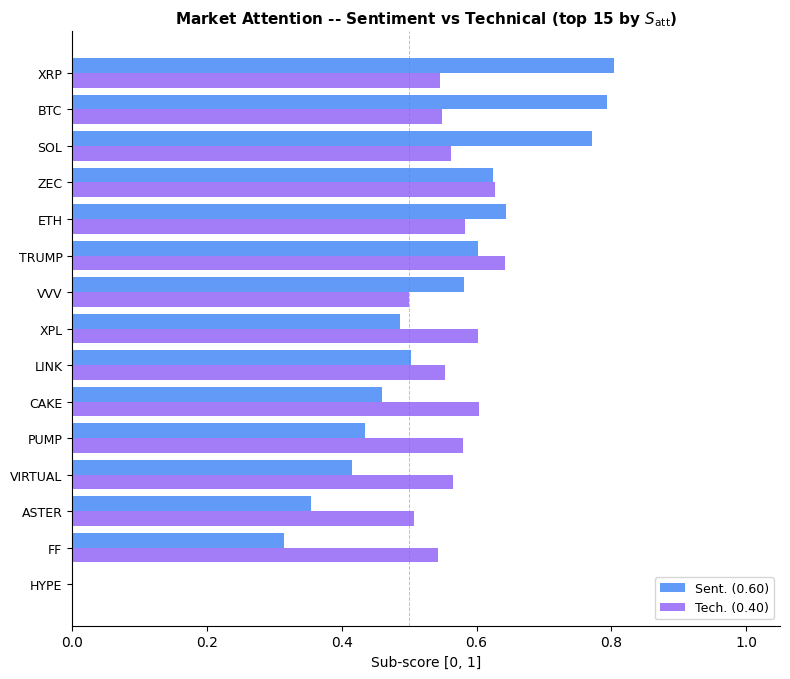

In [11]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing.*')

METRIC_N = 30

def _usd(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return '-'
    if v >= 1e9: return f'${v/1e9:.1f}B'
    if v >= 1e6: return f'${v/1e6:.0f}M'
    if v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:.0f}'

def _fund_fmt(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return '-'
    return f'{float(v)*100:+.4f}%'

# used by all per-bucket cells for row highlighting
_CHART_LABEL = {"币安人生": "BinanceLife"}
_chart_label = lambda s: _CHART_LABEL.get(s, s)

_listed_syms = set(scored.loc[scored['already_listed'], 'symbol'])
def _hl(row):
    return (['background-color: #e8d5f5'] * len(row)
            if row['Token'] in _listed_syms else [''] * len(row))

# ── Market Attention ─────────────────────────────────────────────────────
print('=' * 60)
print('MARKET ATTENTION  (weight 20 pts)')
print('Sub-scores: s_sent (0.60)  s_tech (0.40)')
print('=' * 60)

att = scored.sort_values('S_att', ascending=False).head(METRIC_N).copy()
att.index = range(1, len(att) + 1)
_fmt = lambda v: f'{v:.3f}' if _ok(v) else '-'

disp_att = pd.DataFrame({
    'Token':              att['symbol'],
    'Att. Score':         att['S_att'].map(lambda v: f'{v:.1f}'),
    'Sent. Score (0.60)': att['s_sent'].map(_fmt),
    'Tech. Score (0.40)': att['s_tech'].map(_fmt),
    'Sentiment /10':      att['sentiment_score'].map(lambda v: f'{v:.1f}/10' if _ok(v) else '-'),
    'Tech 1h /10':        att['technical_1h'].map(lambda v: f'{v:.1f}/10' if _ok(v) else '-'),
    'Tech 1d /10':        att['technical_1d'].map(lambda v: f'{v:.1f}/10' if _ok(v) else '-'),
    'KOL Score':          att['sentiment_kol'].map(lambda v: f'{v:.1f}' if _ok(v) else '-'),
})
disp_att.index = att.index
display(disp_att.style.apply(_hl, axis=1)
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# Chart: s_sent vs s_tech horizontal bars
n_show = min(15, len(att))
sub = att.head(n_show)
syms = [_chart_label(s) for s in sub['symbol']]
s_sent_vals = [_f(v) for v in sub['s_sent']]
s_tech_vals = [_f(v) for v in sub['s_tech']]
x = np.arange(n_show)

fig, ax = plt.subplots(figsize=(8, n_show * 0.38 + 1.2))
ax.barh(x,       s_sent_vals, height=0.4, color='#3b82f6', alpha=0.80, label='Sent. (0.60)')
ax.barh(x + 0.4, s_tech_vals, height=0.4, color='#8b5cf6', alpha=0.80, label='Tech. (0.40)')
ax.set_yticks(x + 0.2)
ax.set_yticklabels(syms, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Sub-score [0, 1]')
ax.set_title(r'Market Attention -- Sentiment vs Technical (top 15 by $S_{\mathrm{att}}$)',
             fontsize=11, fontweight='bold')
ax.axvline(0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Price Action


PRICE ACTION  (weight 15 pts)
Sub-scores: s_1h (0.25)  s_24h (0.25)  s_dir (0.25)  s_corr (0.25)


,Token,Price Score,$s_{1h}$ (0.25),$s_{24h}$ (0.25),$s_{\text{dir}}$ (0.25),$s_{\text{corr}}$ (0.25),"$\rho_{\text{BTC},30d}$",24h Change
1,ZEC,73.4,1.000,0.738,0.571,0.626,+0.37,+14.8%
2,HYPE,61.2,0.838,0.365,0.714,0.532,+0.47,+7.3%
3,XPL,50.2,0.722,0.090,0.714,0.480,+0.52,+1.8%
4,VVV,48.7,0.504,0.000,0.571,0.871,+0.13,-0.5%
5,VIRTUAL,46.9,0.780,0.070,0.571,0.455,+0.55,+1.4%
6,PUMP,46.2,0.520,0.213,0.714,0.400,+0.60,+4.3%
7,TRUMP,44.3,0.606,0.000,0.571,0.594,+0.41,-2.7%
8,FF,44.3,0.550,0.000,0.429,0.795,+0.21,-9.1%
9,SOL,38.0,0.694,0.170,0.571,0.086,+0.91,+3.4%
10,CAKE,36.7,0.468,0.166,0.571,0.263,+0.74,+3.3%


**Note:** $s_{24h}$ uses the Binance futures ticker `priceChangePercent` (converted to decimal), falling back to the spot ticker for tokens without a Binance perp. Tokens with neither source show '--'; $s_{24h}$ weight redistributed to remaining sub-scores via renorm. $s_{24h}$ rewards positive changes only ($s_{24h} = 0$ when $\Delta p_{24h} \leq 0$).

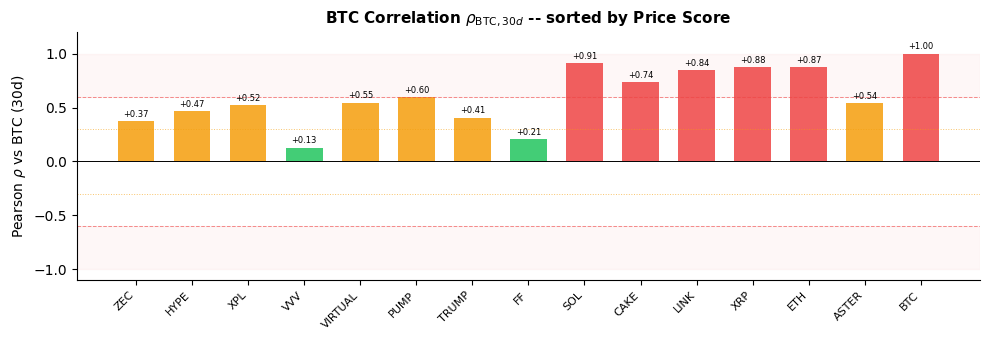

In [12]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing.*')

# ── Price Action ─────────────────────────────────────────────────────────
print('=' * 60)
print('PRICE ACTION  (weight 15 pts)')
print('Sub-scores: s_1h (0.25)  s_24h (0.25)  s_dir (0.25)  s_corr (0.25)')
print('=' * 60)

price = scored.sort_values('S_price', ascending=False).head(METRIC_N).copy()
price.index = range(1, len(price) + 1)

disp_price = pd.DataFrame({
    'Token':            price['symbol'],
    'Price Score':      price['S_price'].map(lambda v: f'{v:.1f}'),
    r'$s_{1h}$ (0.25)':   price['s_1h'].map(_fmt),
    r'$s_{24h}$ (0.25)':  price['s_24h'].map(_fmt),
    r'$s_{\text{dir}}$ (0.25)': price['s_dir'].map(_fmt),
    r'$s_{\text{corr}}$ (0.25)': price['s_corr'].map(_fmt),
    r'$\rho_{\text{BTC},30d}$': price['rho_btc_30d'].map(lambda v: f'{v:+.2f}' if _ok(v) else '-'),
    '24h Change':       price['day_change'].map(lambda v: f'{v*100:+.1f}%' if _ok(v) else '-'),
})
disp_price.index = price.index
display(disp_price.style.apply(_hl, axis=1)
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
from IPython.display import Markdown
display(Markdown(
    r"**Note:** $s_{24h}$ uses the Binance futures ticker `priceChangePercent` (converted to decimal), falling back to the spot ticker for tokens without a Binance perp. "
    r"Tokens with neither source show '--'; $s_{24h}$ weight redistributed to remaining sub-scores via renorm. "
    r"$s_{24h}$ rewards positive changes only ($s_{24h} = 0$ when $\Delta p_{24h} \leq 0$)."
))

# BTC correlation bar
rhos  = price['rho_btc_30d'].tolist()
syms2 = [_chart_label(s) for s in price['symbol']]
n2    = len(syms2)
colors2 = ['#22c55e' if (v is not None and abs(v) < 0.3)
           else '#f59e0b' if (v is not None and abs(v) < 0.6)
           else '#ef4444' if v is not None else '#d1d5db'
           for v in rhos]
x2 = np.arange(n2)
fig2, ax2 = plt.subplots(figsize=(max(10, n2 * 0.45), 3.5))
ax2.bar(x2, [v if v is not None else 0 for v in rhos], color=colors2, alpha=0.85, width=0.65)
ax2.axhspan( 0.6,  1.0, alpha=0.04, color='#ef4444')
ax2.axhspan(-1.0, -0.6, alpha=0.04, color='#ef4444')
ax2.axhline(0,    color='black',   linewidth=0.7)
ax2.axhline( 0.6, color='#ef4444', linewidth=0.7, linestyle='--', alpha=0.6)
ax2.axhline(-0.6, color='#ef4444', linewidth=0.7, linestyle='--', alpha=0.6)
ax2.axhline( 0.3, color='#f59e0b', linewidth=0.7, linestyle=':',  alpha=0.6)
ax2.axhline(-0.3, color='#f59e0b', linewidth=0.7, linestyle=':',  alpha=0.6)
for xi, rho in zip(x2, rhos):
    if rho is not None:
        ax2.text(xi, rho + (0.02 if rho >= 0 else -0.04), f'{rho:+.2f}',
                 ha='center', va='bottom' if rho >= 0 else 'top', fontsize=6)
ax2.set_xticks(x2)
ax2.set_xticklabels(syms2, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel(r'Pearson $\rho$ vs BTC (30d)')
ax2.set_ylim(-1.1, 1.2)
ax2.set_title(r'BTC Correlation $\rho_{\mathrm{BTC},30d}$ -- sorted by Price Score',
              fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Volume Acceleration


VOLUME ACCELERATION  (weight 25 pts)
Sub-scores: s_accel (0.50)  s_PS (0.50)


,Token,Vol. Score,Accel. (0.50),P/S Ratio (0.50),Perp Vol 24h,30d Avg Vol,Accel Multiple,P/S Ratio
1,VVV,50.0,0.000,1.000,$42M,$84M,0.5x,4.07x
2,ASTER,50.0,0.000,1.000,$31M,$85M,0.4x,7.28x
3,VIRTUAL,45.3,0.000,0.907,$27M,$39M,0.7x,8.66x
4,LINK,41.4,0.000,0.827,$66M,$118M,0.6x,6.44x
5,CAKE,38.0,0.000,0.759,$5M,$7M,0.7x,3.05x
6,PUMP,37.1,0.142,0.600,$51M,$63M,0.8x,5.16x
7,XPL,35.2,0.304,0.400,$62M,$51M,1.2x,30.39x
8,ETH,30.0,0.000,0.600,$1.4B,$2.7B,0.5x,4.51x
9,TRUMP,25.0,0.500,0.000,$8M,$5M,1.5x,0.36x
10,BTC,24.0,0.000,0.480,$8.8B,$11.8B,0.7x,10.27x


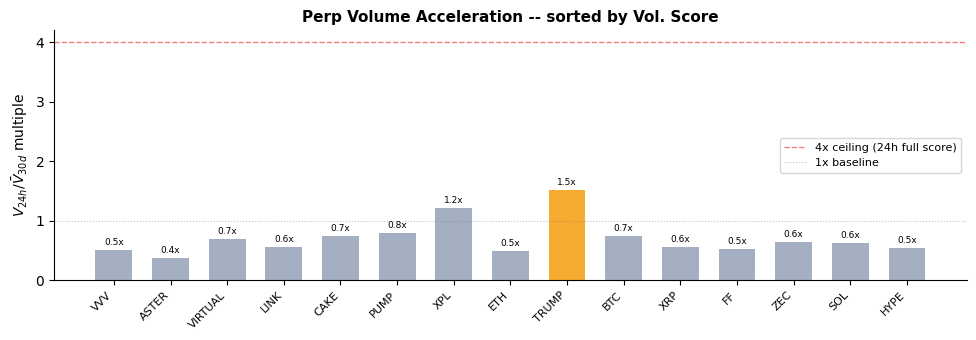

In [13]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing.*')

# ── Volume Acceleration ───────────────────────────────────────────────────
print('=' * 60)
print('VOLUME ACCELERATION  (weight 25 pts)')
print('Sub-scores: s_accel (0.50)  s_PS (0.50)')
print('=' * 60)

vol = scored.sort_values('S_vol', ascending=False).head(METRIC_N).copy()
vol.index = range(1, len(vol) + 1)

disp_vol = pd.DataFrame({
    'Token':              vol['symbol'],
    'Vol. Score':         vol['S_vol'].map(lambda v: f'{v:.1f}'),
    'Accel. (0.50)':      vol['s_accel'].map(_fmt),
    'P/S Ratio (0.50)':   vol['s_PS'].map(_fmt),
    'Perp Vol 24h':       vol['quoteVolume_24h'].map(_usd),
    '30d Avg Vol':        vol['vol_30d_avg'].map(_usd),
    'Accel Multiple':     vol.apply(
        lambda r: f"{r['quoteVolume_24h']/r['vol_30d_avg']:.1f}x"
                  if _ok(r['quoteVolume_24h']) and _ok(r['vol_30d_avg']) and r['vol_30d_avg'] > 0
                  else '-', axis=1),
    'P/S Ratio':          vol['ratio_now'].map(lambda v: f'{v:.2f}x' if _ok(v) else '-'),
})
disp_vol.index = vol.index
display(disp_vol.style.apply(_hl, axis=1)
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# Accel multiple bar
accels = vol.apply(
    lambda r: r['quoteVolume_24h'] / r['vol_30d_avg']
              if _ok(r['quoteVolume_24h']) and _ok(r['vol_30d_avg']) and r['vol_30d_avg'] > 0
              else None, axis=1).tolist()
syms3 = [_chart_label(s) for s in vol['symbol']]
n3    = len(syms3)
x3    = np.arange(n3)
col3  = ['#22c55e' if (v and v >= 3) else '#f59e0b' if (v and v >= 1.5) else '#94a3b8'
         for v in accels]
fig3, ax3 = plt.subplots(figsize=(max(10, n3 * 0.45), 3.5))
ax3.bar(x3, [v if v else 0 for v in accels], color=col3, alpha=0.85, width=0.65)
ax3.axhline(4, color='#ef4444', linewidth=1, linestyle='--', alpha=0.7, label='4x ceiling (24h full score)')
ax3.axhline(1, color='gray',    linewidth=0.8, linestyle=':', alpha=0.5, label='1x baseline')
for xi, v in zip(x3, accels):
    if v:
        ax3.text(xi, v + 0.05, f'{v:.1f}x', ha='center', va='bottom', fontsize=6.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(syms3, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel(r'$V_{24h} / \bar{V}_{30d}$ multiple')
ax3.set_title('Perp Volume Acceleration -- sorted by Vol. Score', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### OI Growth


OI GROWTH  (weight 25 pts)
Sub-scores: s_OI_trend (0.60)  s_OI/Vol (0.40)


,Token,OI Score,OI Trend (0.60),OI/Vol (0.40),$\rho_{7d}$,$\rho_{30d}$,OI Notional,Market Cap,OI/Vol ratio
1,ETH,83.6,0.778,0.924,+0.52,+0.95,$1.3B,$207.7B,0.984x
2,XPL,70.7,0.511,1.000,+0.54,+0.49,$32M,$228M,0.518x
3,TRUMP,60.2,0.349,0.982,+0.87,-0.82,$2M,$1.3B,0.197x
4,BTC,50.3,0.172,1.000,+0.43,-0.37,$6.7B,$1318.2B,0.768x
5,ASTER,49.2,0.592,0.341,+0.55,+0.62,$75M,$1.8B,2.381x
6,SOL,43.4,0.057,1.000,+0.14,-0.38,$79M,$41.3B,0.464x
7,VVV,41.5,0.025,1.000,+0.06,-0.78,$23M,$772M,0.549x
8,VIRTUAL,40.0,0.000,1.000,-0.94,-0.80,$13M,$655M,0.487x
9,XRP,40.0,0.000,1.000,-0.24,-0.47,$25M,$73.6B,0.374x
10,HYPE,40.0,0.000,1.000,-0.74,-0.40,$334M,$14.4B,0.405x


**Note:** `Market Cap` is sourced from the Binance spot list metadata. OI/Vol = OI notional / perp quoteVolume 24h. Healthy range: 0.5–1.0×. Below 0.1 = churn risk; above 5.0 = leverage-stacking risk.

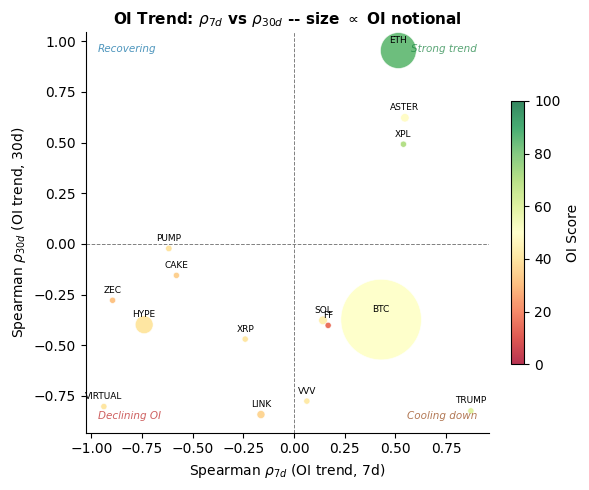

In [14]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing.*')

# ── OI Growth ─────────────────────────────────────────────────────────────
print('=' * 60)
print('OI GROWTH  (weight 25 pts)')
print('Sub-scores: s_OI_trend (0.60)  s_OI/Vol (0.40)')
print('=' * 60)

oi_g = scored.sort_values('S_OI', ascending=False).head(METRIC_N).copy()
oi_g.index = range(1, len(oi_g) + 1)

disp_oi = pd.DataFrame({
    'Token':              oi_g['symbol'],
    'OI Score':           oi_g['S_OI'].map(lambda v: f'{v:.1f}'),
    'OI Trend (0.60)':    oi_g['s_OI_trend'].map(_fmt),
    'OI/Vol (0.40)':      oi_g['s_oi_vol'].map(_fmt),
    r'$\rho_{7d}$':          oi_g['rho_oi_7d'].map(lambda v: f'{v:+.2f}' if _ok(v) else '-'),
    r'$\rho_{30d}$':         oi_g['rho_oi_30d'].map(lambda v: f'{v:+.2f}' if _ok(v) else '-'),
    'OI Notional':        oi_g['oi_notional'].map(_usd),
    'Market Cap':         oi_g['market_cap'].map(lambda v: _usd(v) if _ok(v) else '-'),
    'OI/Vol ratio':       oi_g['oi_vol_ratio'].map(lambda v: f'{v:.3f}x' if _ok(v) else '-'),
})
disp_oi.index = oi_g.index
display(disp_oi.style.apply(_hl, axis=1)
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
from IPython.display import Markdown
display(Markdown(
    r"**Note:** `Market Cap` is sourced from the Binance spot list metadata. "
    r"OI/Vol = OI notional / perp quoteVolume 24h. Healthy range: 0.5–1.0×. "
    r"Below 0.1 = churn risk; above 5.0 = leverage-stacking risk."
))

# Scatter: rho_7d vs rho_30d
rho7s  = [v if _ok(v) else None for v in oi_g['rho_oi_7d']]
rho30s = [v if _ok(v) else None for v in oi_g['rho_oi_30d']]
oi_s   = oi_g['S_OI'].values
oi_not = [v / 1e6 if _ok(v) else 1 for v in oi_g['oi_notional']]
syms4  = [_chart_label(s) for s in oi_g['symbol']]
valid  = [(r7, r30, s, sz, sym) for r7, r30, s, sz, sym
          in zip(rho7s, rho30s, oi_s, oi_not, syms4)
          if r7 is not None and r30 is not None]
if valid:
    r7v, r30v, sv, szv, symv = zip(*valid)
    fig4, ax4 = plt.subplots(figsize=(6, 5))
    sc = ax4.scatter(r7v, r30v, c=sv, cmap='RdYlGn', vmin=0, vmax=100,
                     s=[max(20, sz * 0.5) for sz in szv], alpha=0.80,
                     edgecolors='white', linewidth=0.5)
    for x_, y_, sym_ in zip(r7v, r30v, symv):
        ax4.annotate(sym_, (x_, y_), fontsize=6.5, ha='center', va='bottom',
                     xytext=(0, 4), textcoords='offset points')
    ax4.axvline(0, color='gray', linewidth=0.7, linestyle='--')
    ax4.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax4.set_xlabel(r'Spearman $\rho_{7d}$ (OI trend, 7d)')
    ax4.set_ylabel(r'Spearman $\rho_{30d}$ (OI trend, 30d)')
    ax4.set_title(r'OI Trend: $\rho_{7d}$ vs $\rho_{30d}$ -- size $\propto$ OI notional',
                  fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax4, label='OI Score', fraction=0.03)
    ax4.spines[['top', 'right']].set_visible(False)
    # quadrant labels
    xlim = ax4.get_xlim(); ylim = ax4.get_ylim()
    ax4.text( 0.97,  0.97, 'Strong trend', transform=ax4.transAxes,
              ha='right', va='top', fontsize=7.5, color='#15803d', alpha=0.7,
              style='italic')
    ax4.text( 0.03,  0.97, 'Recovering', transform=ax4.transAxes,
              ha='left', va='top', fontsize=7.5, color='#0369a1', alpha=0.7,
              style='italic')
    ax4.text( 0.97,  0.03, 'Cooling down', transform=ax4.transAxes,
              ha='right', va='bottom', fontsize=7.5, color='#92400e', alpha=0.7,
              style='italic')
    ax4.text( 0.03,  0.03, 'Declining OI', transform=ax4.transAxes,
              ha='left', va='bottom', fontsize=7.5, color='#b91c1c', alpha=0.7,
              style='italic')
    plt.tight_layout()
    plt.show()


---
## Trend Charts

OI (open interest) and daily perp volume over the last 30 days for each top candidate.

- **OI**: `sumOpenInterest × current markPrice` (single-price approximation; tracks shape, not exact notional). Spearman ρ over 7d annotated.
- **Vol**: daily futures quote volume. Dashed line = 30d average.

`PRE` tokens (no Binance perp yet) have no OI or futures kline data and are skipped.

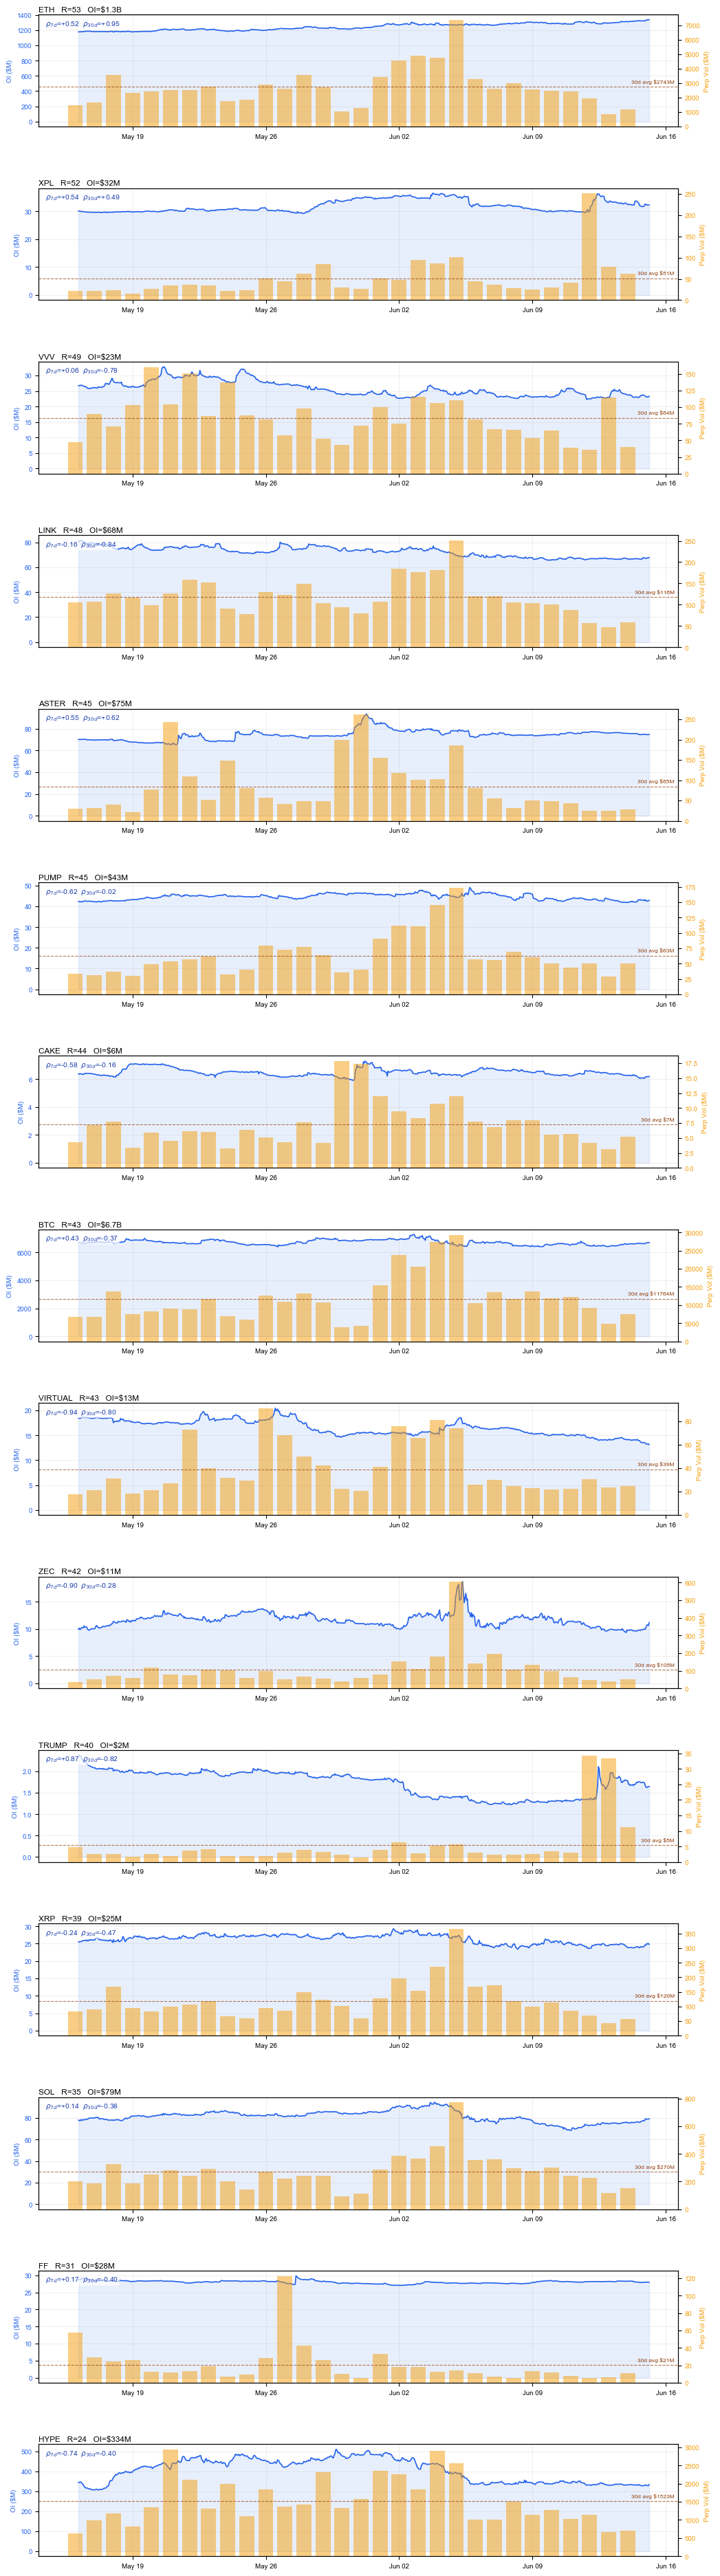

In [15]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from datetime import datetime, timezone as tz
import pandas as pd

# suppress missing-glyph warnings for CJK token names
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph.*missing.*")

_CJK_FONTS = ["Arial Unicode MS", "Hiragino Sans GB", "Noto Sans CJK SC",
               "Source Han Sans SC", "WenQuanYi Micro Hei"]
_avail_fonts = {f.name for f in fm.fontManager.ttflist}
_cjk = next((f for f in _CJK_FONTS if f in _avail_fonts), None)
if _cjk:
    plt.rcParams["font.sans-serif"] = [_cjk] + plt.rcParams.get("font.sans-serif", [])
    plt.rcParams["axes.unicode_minus"] = False

def _ms_to_dt(ms):
    return datetime.fromtimestamp(ms / 1000, tz=tz.utc)

viz_rows = [r for _, r in scored.head(TOP_N).iterrows()
            if r["timing"] != "PRE" and sym_data[r["symbol"]]["oi_hist"]]

nrows = len(viz_rows)
if nrows == 0:
    print("No candidates with OI data to plot.")
else:
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 3.2 * nrows), squeeze=False)

    for i, row in enumerate(viz_rows):
        sym = row["symbol"]
        sd  = sym_data[sym]
        ax  = axes[i][0]

        # OI trend (30d hourly) -- left y-axis
        oi_hist  = sorted(sd["oi_hist"], key=lambda x: x["timestamp"])
        mp       = row["mark_price"] or 1.0
        oi_times = [_ms_to_dt(x["timestamp"]) for x in oi_hist]
        oi_usd   = [float(x["sumOpenInterest"]) * mp / 1e6 for x in oi_hist]

        ax.plot(oi_times, oi_usd, color="#2563eb", linewidth=1.2)
        ax.fill_between(oi_times, oi_usd, alpha=0.10, color="#2563eb")

        # Spearman rho annotation -- top left (blue, OI axis)
        rho7  = row["rho_oi_7d"]
        rho30 = row["rho_oi_30d"]
        ann   = []
        if rho7  is not None and not np.isnan(float(rho7)):
            ann.append(r"$\rho_{7d}$" + f"={float(rho7):+.2f}")
        if rho30 is not None and not np.isnan(float(rho30)):
            ann.append(r"$\rho_{30d}$" + f"={float(rho30):+.2f}")
        if ann:
            ax.annotate("  ".join(ann), xy=(0.01, 0.96), xycoords="axes fraction",
                        fontsize=7.5, color="#1e40af", va="top",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

        ax.set_title(f"{_chart_label(sym)}   R={row['R']:.0f}   OI={_usd(row['oi_notional'])}",
                     fontsize=8.5, fontweight="bold", loc="left", pad=3)
        ax.set_ylabel("OI ($M)", fontsize=7, color="#2563eb")
        ax.tick_params(axis="y", labelcolor="#2563eb", labelsize=7)
        ax.tick_params(axis="x", labelsize=7)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.grid(True, alpha=0.30, linewidth=0.5)

        # Daily perp volume (30d) -- right y-axis
        ax2 = ax.twinx()
        klines = sd["klines"][-31:-1]  # 30 completed candles, matches OI 30d window
        if klines:
            k_times = [_ms_to_dt(k[0]) for k in klines]
            k_vols  = [float(k[7]) / 1e6 for k in klines]
            avg30   = np.mean(k_vols[-30:]) if len(k_vols) >= 7 else np.mean(k_vols)
            ax2.bar(k_times, k_vols, color="#f59e0b", alpha=0.50,
                    width=pd.Timedelta(hours=19))
            ax2.axhline(avg30, color="#92400e", linewidth=0.8, linestyle="--", alpha=0.7)
            # annotate avg directly on dashed line -- right edge, no legend box
            ax2.annotate(f"30d avg ${avg30:.0f}M",
                         xy=(1.0, avg30), xycoords=("axes fraction", "data"),
                         xytext=(-4, 3), textcoords="offset points",
                         fontsize=6, color="#92400e", ha="right", va="bottom")
        else:
            ax2.text(0.5, 0.5, "No kline data", ha="center", va="center",
                     transform=ax2.transAxes, fontsize=8, color="gray")

        ax2.set_ylabel("Perp Vol ($M)", fontsize=7, color="#f59e0b")
        ax2.tick_params(axis="y", labelcolor="#f59e0b", labelsize=7)

    # subplots_adjust instead of tight_layout -- avoids overflow error on large nrows
    plt.subplots_adjust(hspace=0.55)
    plt.show()

warnings.resetwarnings()


### Funding Rate

FUNDING RATE  (weight 15 pts)
Sub-scores: s_fund_level (0.45)  s_flip (0.35)  s_persist (0.20)


,Token,Fund. Score,Fund. Level (0.45),Fund. Flip (0.35),Persist. (0.20),Funding Rate,Perp Basis
1,LINK,82.1,0.667,1.000,0.857,+0.0100%,-0.0568%
2,CAKE,66.2,0.333,1.000,0.810,+0.0050%,-0.1366%
3,PUMP,59.3,0.333,0.722,0.952,+0.0050%,-0.0571%
4,XPL,52.5,0.333,0.500,1.000,+0.0050%,-0.0348%
5,ASTER,52.5,0.333,0.500,1.000,+0.0050%,+0.0001%
6,FF,52.5,0.333,0.500,1.000,+0.0050%,-0.0222%
7,ETH,51.2,0.063,1.000,0.667,+0.0009%,-0.0378%
8,VVV,49.7,0.159,0.889,0.571,+0.0024%,+0.0001%
9,BTC,48.3,0.000,1.000,0.667,-0.0009%,-0.0315%
10,ZEC,48.3,0.190,1.000,0.238,+0.0028%,-0.0228%


**Notes:** $s_{\text{flip}}$ uses 72 h linear decay from last neg$\to$pos flip: **1.0** = flip just occurred; approaches **0.0** as flip ages toward 72 h. No flip detected: **0.5** if all recent funding rates are positive (structurally bullish); **0.0** if currently negative. Funding bars: green = positive rate, red = negative. Dashed lines mark neutral $\pm 0.01\%$ per settlement.

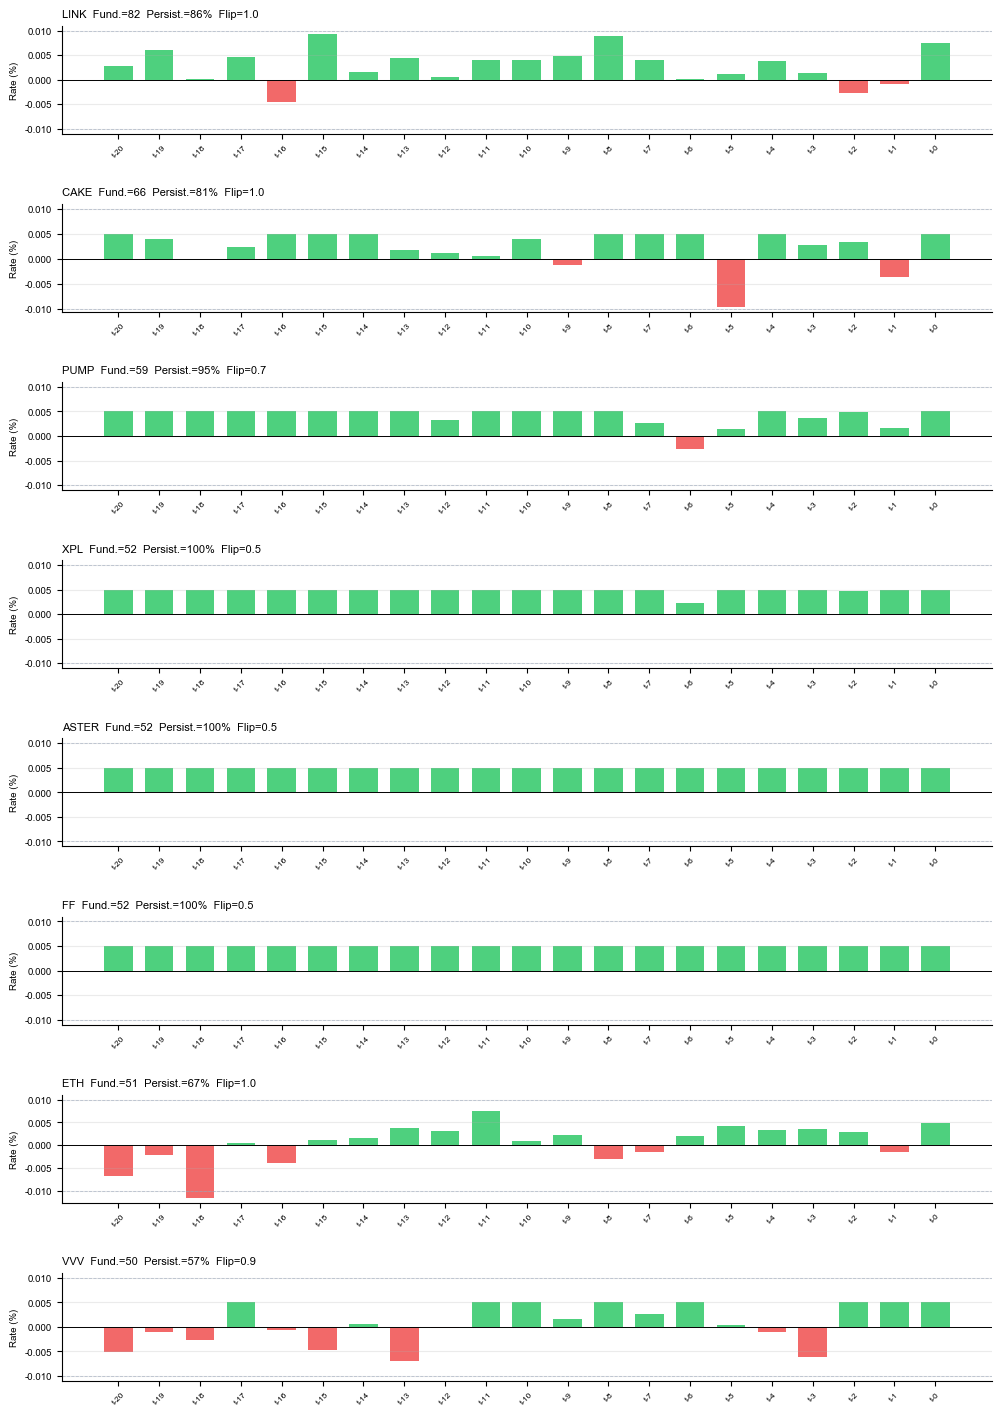

In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing.*')

# ── Funding Rate ────────────────────────────────────────────────────────────
print('=' * 60)
print('FUNDING RATE  (weight 15 pts)')
print('Sub-scores: s_fund_level (0.45)  s_flip (0.35)  s_persist (0.20)')
print('=' * 60)

lev = scored.sort_values('S_lev', ascending=False).head(METRIC_N).copy()
lev.index = range(1, len(lev) + 1)

disp_lev = pd.DataFrame({
    'Token':                lev['symbol'],
    'Fund. Score':          lev['S_lev'].map(lambda v: f'{v:.1f}'),
    'Fund. Level (0.45)':   lev['s_fund_level'].map(_fmt),
    'Fund. Flip (0.35)':    lev['s_flip'].map(_fmt),
    'Persist. (0.20)':      lev['s_persist'].map(_fmt),
    'Funding Rate':         lev['last_funding_rate'].map(_fund_fmt),
    'Perp Basis':           lev['perp_basis'].map(lambda v: f'{v*100:+.4f}%' if _ok(v) else '-'),
})
disp_lev.index = lev.index
display(disp_lev.style.apply(_hl, axis=1)
        .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
from IPython.display import Markdown
display(Markdown(
    r"**Notes:** "
    r"$s_{\text{flip}}$ uses 72 h linear decay from last neg$\to$pos flip: "
    r"**1.0** = flip just occurred; approaches **0.0** as flip ages toward 72 h. "
    r"No flip detected: **0.5** if all recent funding rates are positive (structurally bullish); **0.0** if currently negative. "
    r"Funding bars: green = positive rate, red = negative. "
    r"Dashed lines mark neutral $\pm 0.01\%$ per settlement."
))

# Funding rate timeline for top-8 by S_lev
fund_rows = [r for _, r in lev.iterrows()
             if sym_data[r['symbol']]['funding_hist']][:8]
if not fund_rows:
    print('No funding history available.')
else:
    nf = len(fund_rows)
    fig5, axes5 = plt.subplots(nf, 1, figsize=(12, 2.2 * nf), squeeze=False)
    for i, row in enumerate(fund_rows):
        sym  = row['symbol']
        hist = sorted(sym_data[sym]['funding_hist'],
                      key=lambda x: x['fundingTime'])[-21:]
        rates  = [float(x['fundingRate']) * 100 for x in hist]
        xs     = list(range(len(rates)))
        colors = ['#22c55e' if r > 0 else '#ef4444' for r in rates]
        ax = axes5[i][0]
        ax.bar(xs, rates, color=colors, alpha=0.80, width=0.7)
        ax.axhline(0,     color='black',   linewidth=0.7)
        ax.axhline( 0.01, color='#94a3b8', linewidth=0.6, linestyle='--', alpha=0.6)
        ax.axhline(-0.01, color='#94a3b8', linewidth=0.6, linestyle='--', alpha=0.6)
        s_p = row.get('s_persist') or 0
        s_f = row.get('s_flip') or 0
        ax.set_title(f'{_chart_label(sym)}  Fund.={row["S_lev"]:.0f}  Persist.={s_p:.0%}  Flip={s_f:.1f}',
                     fontsize=8, fontweight='bold', loc='left')
        ax.set_xticks(xs)
        ax.set_xticklabels([f't-{len(rates)-1-j}' for j in xs], fontsize=6, rotation=45)
        ax.set_ylabel('Rate (%)', fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.25)
        ax.spines[['top','right']].set_visible(False)
    plt.subplots_adjust(hspace=0.65)
    plt.show()


### Overview


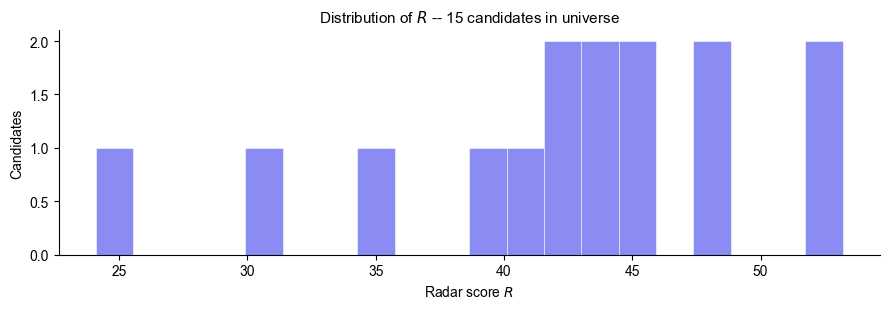

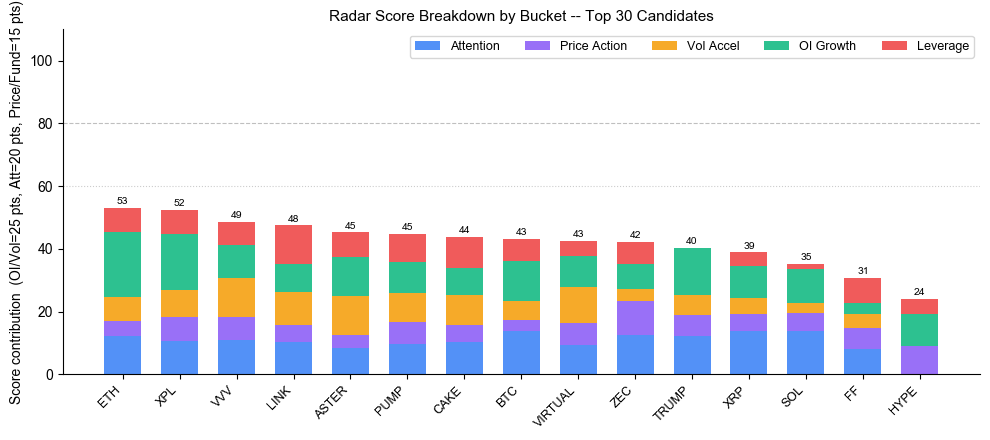

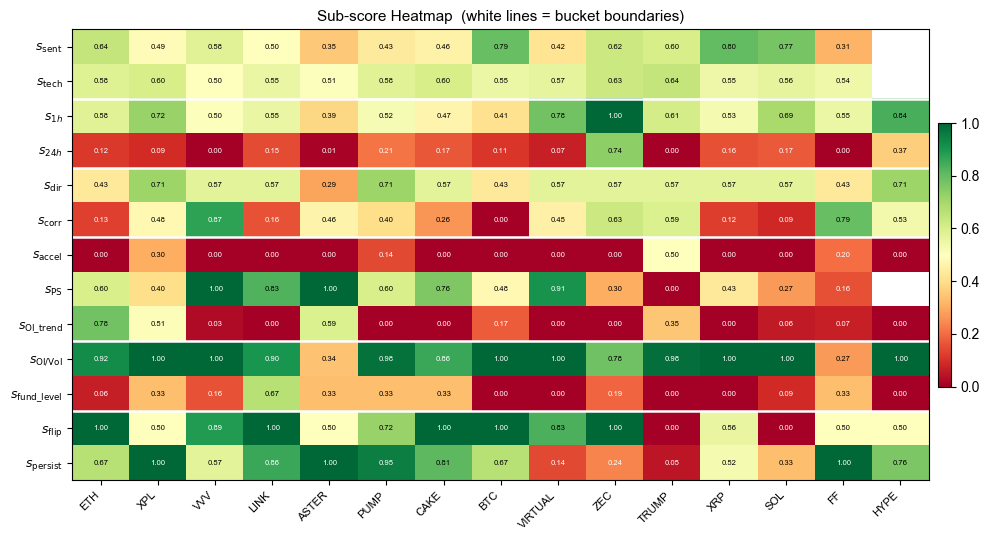

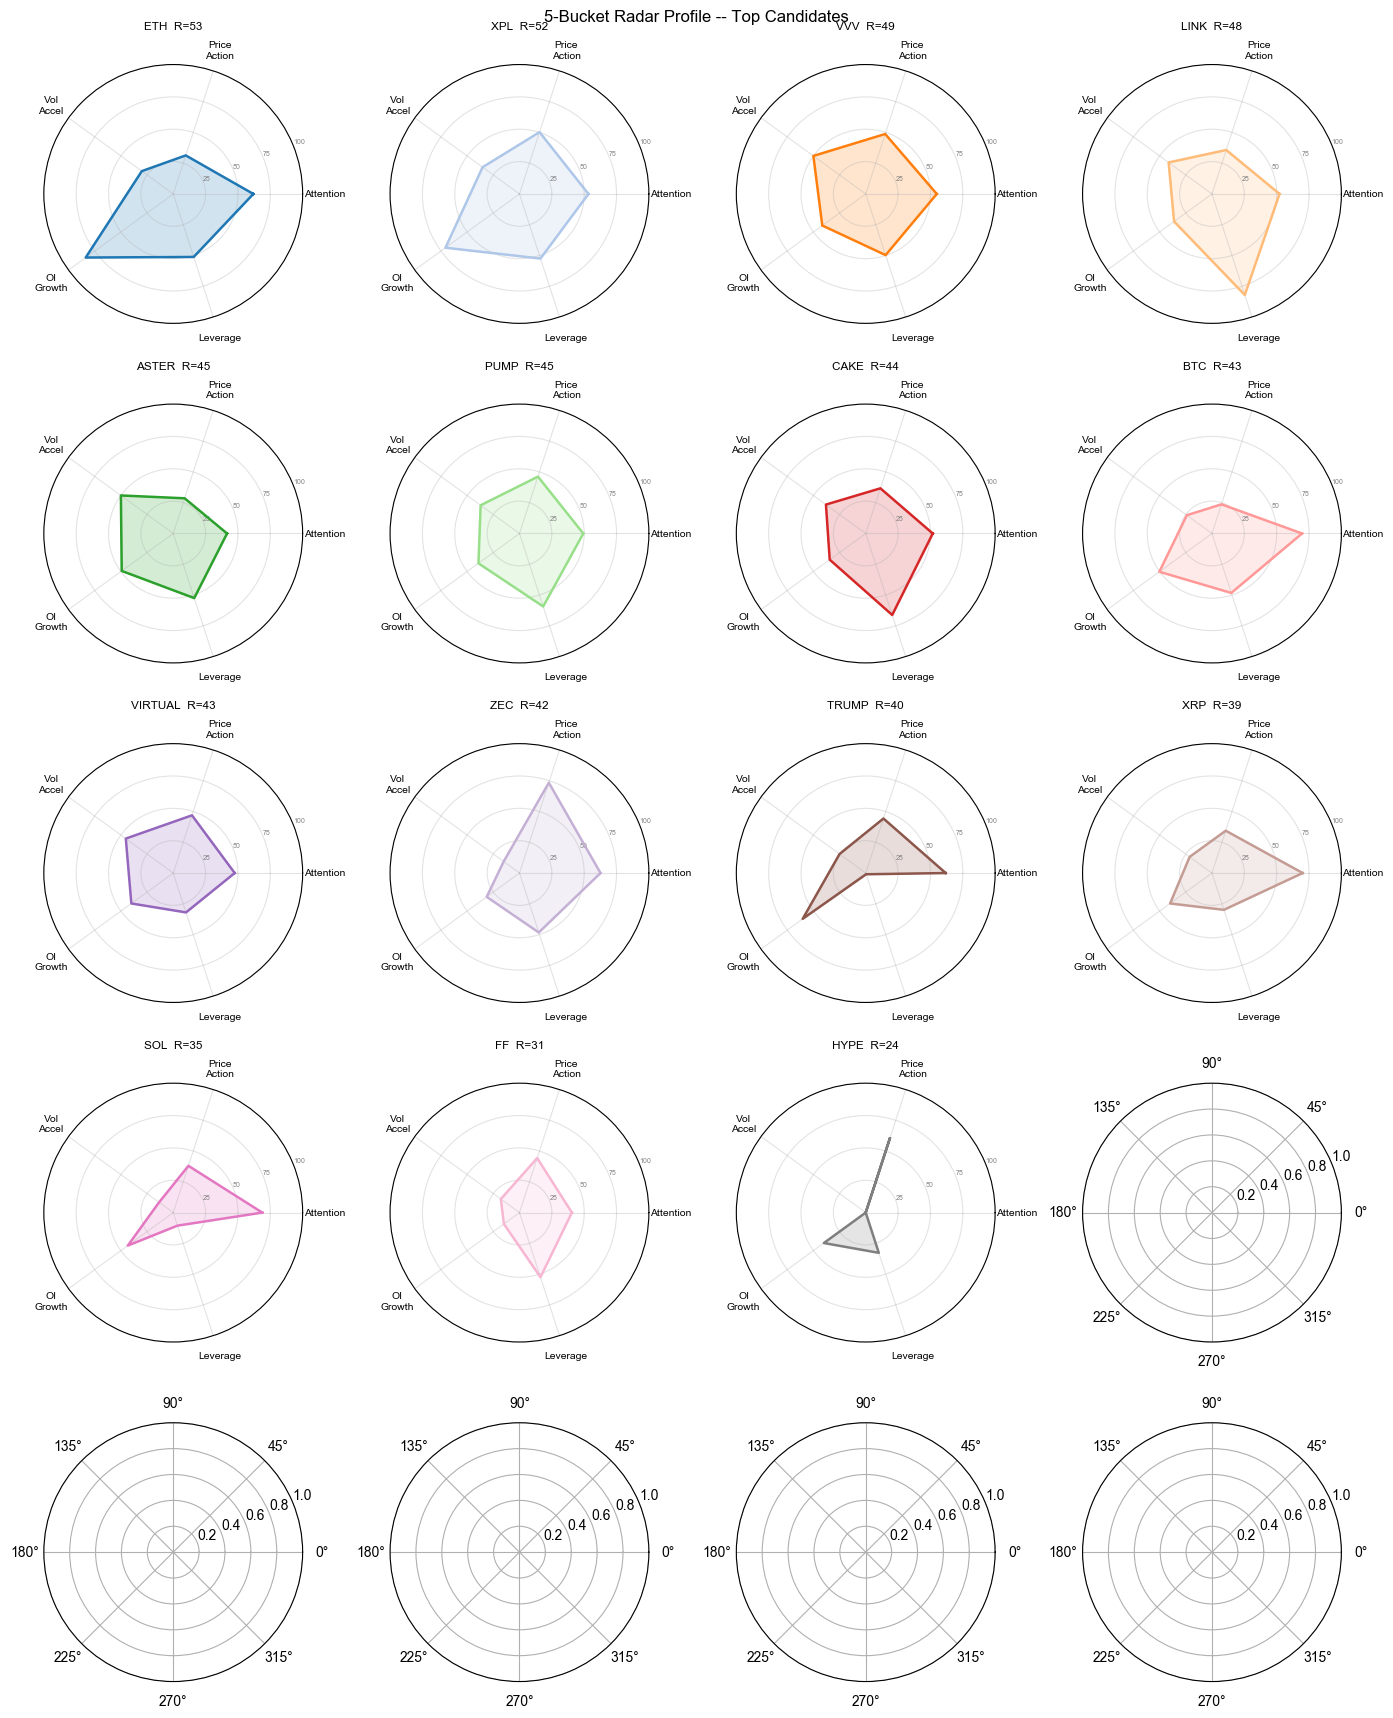

In [17]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph.*missing.*")

# ── Overview ──────────────────────────────────────────────────────────────────
# Score distribution
fig_d, ax_d = plt.subplots(figsize=(9, 3.2))
ax_d.hist(scored["R"], bins=20, color="#6366f1", alpha=0.75,
          edgecolor="white", linewidth=0.5)
if len(scored) >= TOP_N:
    cutoff = float(scored.iloc[TOP_N - 1]["R"])
    ax_d.axvline(cutoff, color="#ef4444", linewidth=1.4, linestyle="--")
    ax_d.text(cutoff + 0.5, ax_d.get_ylim()[1] * 0.85,
              f"Top-{TOP_N} cutoff\n(R={cutoff:.0f})", fontsize=8, color="#ef4444")
ax_d.set_xlabel(r"Radar score $R$")
ax_d.set_ylabel("Candidates")
ax_d.set_title(f"Distribution of $R$ -- {len(scored)} candidates in universe",
               fontsize=11, fontweight="bold")
ax_d.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Bucket breakdown stacked bar (top-N by R)
_syms    = [_chart_label(s) for s in scored.head(TOP_N)["symbol"]]
_n       = len(_syms)
_x       = np.arange(_n)
_buckets  = ["S_att","S_price","S_vol","S_OI","S_lev"]
_labels   = ["Attention","Price Action","Vol Accel","OI Growth","Leverage"]
_colors   = ["#3b82f6","#8b5cf6","#f59e0b","#10b981","#ef4444"]
_bkt_pts  = [20, 15, 25, 25, 15]   # bucket weights (must sum to 100)

fig_b, ax_b = plt.subplots(figsize=(max(10, _n * 0.55), 4.5))
bottom = np.zeros(_n)
for bucket, label, color, pts in zip(_buckets, _labels, _colors, _bkt_pts):
    vals = scored.head(TOP_N)[bucket].fillna(0).values * pts / 100
    ax_b.bar(_x, vals, bottom=bottom, label=label, color=color, alpha=0.88, width=0.65)
    bottom += vals
r_vals = scored.head(TOP_N)["R"].values
for xi, rval in zip(_x, r_vals):
    ax_b.text(xi, rval + 0.5, f"{rval:.0f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax_b.set_xticks(_x)
ax_b.set_xticklabels(_syms, rotation=45, ha="right", fontsize=9)
ax_b.set_ylabel("Score contribution  (OI/Vol=25 pts, Att=20 pts, Price/Fund=15 pts)")
ax_b.set_ylim(0, 110)
ax_b.set_title(f"Radar Score Breakdown by Bucket -- Top {TOP_N} Candidates",
               fontsize=11, fontweight="bold")
ax_b.legend(loc="upper right", fontsize=9, ncol=5)
ax_b.axhline(80, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax_b.axhline(60, color="gray", linestyle=":",  linewidth=0.8, alpha=0.4)
ax_b.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Sub-score heatmap
SUB_SCORES = [
    ("s_sent",       r"$s_{\mathrm{sent}}$"),
    ("s_tech",       r"$s_{\mathrm{tech}}$"),
    ("s_1h",         r"$s_{1h}$"),
    ("s_24h",        r"$s_{24h}$"),
    ("s_dir",        r"$s_{\mathrm{dir}}$"),
    ("s_corr",       r"$s_{\mathrm{corr}}$"),
    ("s_accel",      r"$s_{\mathrm{accel}}$"),
    ("s_PS",         r"$s_{\mathrm{PS}}$"),
    ("s_OI_trend",   r"$s_{\mathrm{OI\_trend}}$"),
    ("s_oi_vol",     r"$s_{\mathrm{OI/Vol}}$"),
    ("s_fund_level", r"$s_{\mathrm{fund\_level}}$"),
    ("s_flip",       r"$s_{\mathrm{flip}}$"),
    ("s_persist",    r"$s_{\mathrm{persist}}$"),
]
BUCKET_SEP = [2, 4, 6, 9, 11]
cols   = [c for c, _ in SUB_SCORES]
labels = [lbl for _, lbl in SUB_SCORES]
mat    = scored.head(TOP_N)[cols].astype(float).values

fig_h, ax_h = plt.subplots(figsize=(max(10, _n * 0.55), 5.5))
im = ax_h.imshow(mat.T, aspect="auto", cmap=plt.cm.RdYlGn, vmin=0, vmax=1,
                 interpolation="nearest")
for sep in BUCKET_SEP:
    ax_h.axhline(sep - 0.5, color="white", linewidth=1.8)
for row_i in range(len(labels)):
    for col_i in range(_n):
        val = mat[col_i, row_i]
        if not np.isnan(val):
            ax_h.text(col_i, row_i, f"{val:.2f}", ha="center", va="center",
                      fontsize=5.5, color="black" if 0.25 < val < 0.85 else "white")
ax_h.set_xticks(range(_n))
ax_h.set_xticklabels(_syms, rotation=45, ha="right", fontsize=8)
ax_h.set_yticks(range(len(labels)))
ax_h.set_yticklabels(labels, fontsize=9)
ax_h.set_title("Sub-score Heatmap  (white lines = bucket boundaries)",
               fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax_h, fraction=0.015, pad=0.01)
plt.tight_layout()
plt.show()

# Radar spider (top-8 by R)
RADAR_N = min(TOP_N, 20)
buckets = ["Attention","Price\nAction","Vol\nAccel","OI\nGrowth","Leverage"]
angles  = np.linspace(0, 2 * np.pi, len(buckets), endpoint=False).tolist() + [0]

N_COLS  = 4
N_ROWS  = (RADAR_N + N_COLS - 1) // N_COLS
cmap20  = plt.colormaps['tab20'].resampled(RADAR_N)
PALETTE = [cmap20(i) for i in range(RADAR_N)]
fig_r, axes_r = plt.subplots(N_ROWS, N_COLS,
                              figsize=(14, 3.5 * N_ROWS),
                              subplot_kw=dict(polar=True))
axes_r_flat = np.array(axes_r).reshape(-1)
fig_r.suptitle("5-Bucket Radar Profile -- Top Candidates", fontsize=12, fontweight="bold")
for idx, (_, row) in enumerate(scored.head(RADAR_N).iterrows()):
    ax_r = axes_r_flat[idx]
    vals = [row["S_att"]/100, row["S_price"]/100, row["S_vol"]/100,
            row["S_OI"]/100, row["S_lev"]/100] + [row["S_att"]/100]
    ax_r.plot(angles, vals, color=PALETTE[idx], linewidth=1.8)
    ax_r.fill(angles, vals, color=PALETTE[idx], alpha=0.20)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(buckets, fontsize=7.5)
    ax_r.set_ylim(0, 1)
    ax_r.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax_r.set_yticklabels(["25","50","75","100"], fontsize=5, color="gray")
    ax_r.tick_params(axis="x", pad=5)
    ax_r.set_title(f"{_chart_label(row['symbol'])}  R={row['R']:.0f}",
                   fontsize=8.5, fontweight="bold", pad=8)
    ax_r.grid(True, alpha=0.35)
for idx in range(RADAR_N, N_ROWS * N_COLS):
    axes_r_flat[idx].set_visible(False)
plt.tight_layout()
plt.show()


### Final Ranking

Combined $R$ score across all five buckets, sorted descending.

| Column | Description |
|---|---|
| R | Radar score [0--100]. Higher = stronger candidate signal. Not a safety score. |
| Timing | **PRE** = no Binance perp yet; **NEW** = Binance perp < 30d; **EST** = established |
| Att / Price / Vol / OI / Lev | Bucket scores [0--100] |
| Vol 24h | Binance perp 24h quote volume |
| OI $ | Open interest notional |
| Fund | Most recent 8h funding rate (signed) |
| Sent | Binance AI sentiment score [0--10] |
| Mon | Binance Monitoring flag |

Purple rows = already listed on RISEx. Amber = Monitoring flag.


In [18]:
def _usd(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return "-"
    if v >= 1e9: return f"${v/1e9:.1f}B"
    if v >= 1e6: return f"${v/1e6:.0f}M"
    if v >= 1e3: return f"${v/1e3:.0f}K"
    return f"${v:.0f}"

def _fund_fmt(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return "-"
    return f"{float(v)*100:+.4f}%"

DISPLAY = [
    "symbol", "already_listed", "R", "timing",
    "S_att", "S_price", "S_vol", "S_OI", "S_lev",
    "quoteVolume_24h", "oi_notional", "last_funding_rate",
    "market_cap", "fdv", "sentiment_score",
    "is_alpha", "monitoring", "chips",
]
top = scored.head(TOP_N)[DISPLAY].copy()

# Build token label: append ✓ if listed on RISEx, * if on monitoring list
top["symbol"] = top.apply(
    lambda r: r["symbol"]
              + ("✓" if r["already_listed"] else "")
              + ("*"      if r["monitoring"]     else ""),
    axis=1)

top["quoteVolume_24h"]   = top["quoteVolume_24h"].apply(_usd)
top["oi_notional"]       = top["oi_notional"].apply(_usd)
top["last_funding_rate"]  = top["last_funding_rate"].apply(_fund_fmt)
top["market_cap"]        = top["market_cap"].apply(lambda v: _usd(v) if _ok(v) else "-")
top["fdv"]               = top["fdv"].apply(lambda v: _usd(v) if _ok(v) else "-")
top["sentiment_score"]   = top["sentiment_score"].apply(lambda v: f"{v:.1f}/10" if _ok(v) else "-")
for _sc in ["R", "S_att", "S_price", "S_vol", "S_OI", "S_lev"]:
    top[_sc] = top[_sc].apply(lambda v: f"{float(v):.2f}" if _ok(v) else "-")

top.columns = ["Token", "_listed", "R", "Timing",
               "Att", "Price", "Vol", "OI", "Fund",
               "Vol 24h", "OI $", "Rate",
               "MCap", "FDV", "Sent",
               "_α", "_mon", "Reason chips"]
top.index = range(1, len(top) + 1)

def _style(row):
    base = [""] * len(row)
    if row["_listed"]:
        base = ["background-color: #e8d5f5"] * len(row)
    if row["_mon"]:
        base = ["background-color: #fff3cd"] * len(row)
    if row["_α"]:
        base = ["background-color: #e0f2fe"] * len(row)
    if row["Timing"] == "PRE":
        i = list(row.index).index("Timing")
        base[i] = "background-color: #d4edda; font-weight: bold"
    elif row["Timing"] == "NEW":
        i = list(row.index).index("Timing")
        base[i] = "background-color: #cce5ff; font-weight: bold"
    return base

from IPython.display import Markdown
display(
    top.style
       .apply(_style, axis=1)
       .set_properties(**{"text-align": "left", "white-space": "nowrap"})
       .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
       .hide(axis=1, subset=["_listed", "_α", "_mon"])
)
display(Markdown("""
<div style="font-size:0.85em; line-height:1.8; border:1px solid #e2e8f0; border-radius:6px; padding:10px 14px; background:#fafafa; margin-top:6px">

| | |
|---|---|
| **R** | Composite radar score (0–100) |
| **Att / Price / Vol / OI / Fund** | Bucket scores contributing to R |
| **Vol 24h** | 24h perpetual trading volume |
| **OI $** | Open interest notional |
| **Rate** | Latest funding rate |
| **MCap** | Spot market capitalisation |
| **FDV** | Fully diluted valuation |
| **Sent** | Sentiment score (0–10) |

**Row colors** &nbsp;
<span style="background:#e0f2fe;padding:1px 8px;border-radius:3px">blue</span> Binance Alpha &nbsp;
<span style="background:#e8d5f5;padding:1px 8px;border-radius:3px">purple</span> Already on RISEx &nbsp;
<span style="background:#fff3cd;padding:1px 8px;border-radius:3px">yellow</span> Binance monitoring list

**Token suffixes** &nbsp; `TOKEN✓` = listed on RISEx &nbsp; `TOKEN*` = on Binance monitoring list

</div>
"""))

,Token,R,Timing,Att,Price,Vol,OI,Fund,Vol 24h,OI $,Rate,MCap,FDV,Sent,Reason chips
1,ETH✓,53.20,EST,61.90,31.30,30.00,83.60,51.20,$1.4B,$1.3B,+0.0009%,$207.7B,$207.7B,6.4/10,OI rho=0.52 | OI/Vol 0.98x | Sent 6.4/10
2,XPL,52.50,EST,53.30,50.20,35.20,70.70,52.50,$62M,$32M,+0.0050%,$228M,$907M,4.9/10,OI/Vol 0.52x | OI rho=0.54 | Sent 4.9/10
3,VVV✓,48.60,EST,54.90,48.70,50.00,41.50,49.70,$42M,$23M,+0.0024%,$772M,-,5.8/10,P/S 4.1x | OI/Vol 0.55x | Sent 5.8/10
4,LINK,47.50,EST,52.20,35.70,41.40,36.20,82.10,$66M,$68M,+0.0100%,$6.0B,$8.2B,5.0/10,P/S 6.4x | OI/Vol 1.03x | Sent 5.0/10
5,ASTER,45.30,EST,41.60,28.60,50.00,49.20,52.50,$31M,$75M,+0.0050%,$1.8B,$5.1B,3.5/10,P/S 7.3x | OI rho=0.55 | Sent 3.5/10
6,PUMP,44.80,EST,49.30,46.20,37.10,39.20,59.30,$51M,$43M,+0.0050%,$1.1B,$1.6B,4.3/10,OI/Vol 0.85x | P/S 5.2x | Sent 4.3/10
7,CAKE,43.90,EST,51.80,36.70,38.00,34.40,66.20,$5M,$6M,+0.0050%,$491M,$558M,4.6/10,P/S 3.0x | OI/Vol 1.14x | Sent 4.6/10
8,BTC✓,43.30,EST,69.60,23.70,24.00,50.30,48.30,$8.8B,$6.7B,-0.0009%,$1318.2B,$1381.2B,7.9/10,OI/Vol 0.77x | Sent 7.9/10 | P/S 10.3x
9,VIRTUAL,42.70,EST,47.50,46.90,45.30,40.00,32.00,$27M,$13M,-0.0013%,$655M,$655M,4.2/10,P/S 8.7x | OI/Vol 0.49x | Sent 4.2/10
10,ZEC✓,42.40,EST,62.60,73.40,15.10,31.30,48.30,$67M,$11M,+0.0028%,$8.1B,$10.2B,6.2/10,OI/Vol 0.17x | Sent 6.2/10 | Fund Flip



<div style="font-size:0.85em; line-height:1.8; border:1px solid #e2e8f0; border-radius:6px; padding:10px 14px; background:#fafafa; margin-top:6px">

| | |
|---|---|
| **R** | Composite radar score (0–100) |
| **Att / Price / Vol / OI / Fund** | Bucket scores contributing to R |
| **Vol 24h** | 24h perpetual trading volume |
| **OI $** | Open interest notional |
| **Rate** | Latest funding rate |
| **MCap** | Spot market capitalisation |
| **FDV** | Fully diluted valuation |
| **Sent** | Sentiment score (0–10) |

**Row colors** &nbsp;
<span style="background:#e0f2fe;padding:1px 8px;border-radius:3px">blue</span> Binance Alpha &nbsp;
<span style="background:#e8d5f5;padding:1px 8px;border-radius:3px">purple</span> Already on RISEx &nbsp;
<span style="background:#fff3cd;padding:1px 8px;border-radius:3px">yellow</span> Binance monitoring list

**Token suffixes** &nbsp; `TOKEN✓` = listed on RISEx &nbsp; `TOKEN*` = on Binance monitoring list

</div>
